# Responsible Credit Scoring — Milestone 4: Final Analysis
## Model Refinement, Fairness Audit, and Segmentation
### Student: Carlos Elizondo | Student Number: 500890062
### Supervisor: Tamer Abdou

This notebook extends 03_Baseline_Modeling.ipynb (Milestone 3) with the analyses
required for the Milestone 4 Final Report: stratified k-fold cross-validation,
hyperparameter tuning, an 89-vs-50 feature comparison, the ethically constrained
Model B, a fairness audit, SHAP-based feature importance, probability calibration,
the interest rate cap, and customer segmentation. It loads the cleaned feature
matrix produced at the end of Notebook 03 rather than repeating the cleaning and
encoding steps.

## 1. Setup & Load

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, fbeta_score, roc_auc_score, confusion_matrix)
from scipy.stats import ttest_rel

RANDOM_STATE = 42

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/CIND820_Project/cleaned_encoded_matrix.csv'
df = pd.read_csv(DATA_PATH)

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df['TARGET'].value_counts(normalize=True).round(3))

Mounted at /content/drive
Loaded: 307,504 rows x 196 columns
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


## 2. Rebuilding the Feature Set and Train/Test Split

Reusing the 89-feature consensus set and the identical stratified split from
Notebook 03, so results in this notebook are directly comparable to the
Milestone 3 baseline.

In [ ]:
final_feature_selection = [
    'AGE_YEARS', 'AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL',
    'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
    'BURBAL_MONTHS_CLOSED', 'BURBAL_MONTHS_OVERDUE', 'BURBAL_TOTAL_MONTHS', 'BUR_ACTIVE_LOANS',
    'BUR_AVG_DAYS_OVERDUE', 'BUR_AVG_UTILIZATION', 'BUR_MAX_OVERDUE_AMT', 'BUR_TOTAL_DEBT',
    'BUR_TOTAL_LOANS', 'BUR_TOTAL_PROLONGED', 'CC_AVG_PAYMENT_RATIO', 'CC_AVG_UTILIZATION',
    'CC_MAX_DPD', 'CC_TOTAL_CARDS', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'CODE_GENDER',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION',
    'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EMPLOYED_YEARS', 'EXT_SOURCE_1',
    'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_MON',
    'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_QRT', 'FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_YEAR',
    'FLAG_MISSING_BURBAL_MONTHS_CLOSED', 'FLAG_MISSING_BURBAL_MONTHS_OVERDUE',
    'FLAG_MISSING_BURBAL_TOTAL_MONTHS', 'FLAG_MISSING_BUR_ACTIVE_LOANS',
    'FLAG_MISSING_BUR_AVG_DAYS_OVERDUE', 'FLAG_MISSING_BUR_AVG_UTILIZATION',
    'FLAG_MISSING_BUR_TOTAL_DEBT', 'FLAG_MISSING_BUR_TOTAL_LOANS',
    'FLAG_MISSING_BUR_TOTAL_PROLONGED', 'FLAG_MISSING_CC_AVG_PAYMENT_RATIO',
    'FLAG_MISSING_CC_AVG_UTILIZATION', 'FLAG_MISSING_CC_MAX_DPD', 'FLAG_MISSING_CC_TOTAL_CARDS',
    'FLAG_MISSING_DAYS_EMPLOYED', 'FLAG_MISSING_EMPLOYED_YEARS', 'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY', 'INST_AVG_PAYMENT_DELAY', 'INST_AVG_UNDERPAYMENT', 'INST_COUNT_LATE',
    'INST_MAX_DAYS_PAST_DUE', 'INST_RATIO_LATE', 'INST_TOTAL_RECORDS', 'NAME_CONTRACT_TYPE',
    'NAME_EDUCATION_TYPE_RANKED', 'NAME_FAMILY_STATUS_Single / not married',
    'NAME_HOUSING_TYPE_With parents', 'NAME_INCOME_TYPE_Pensioner',
    'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Working', 'OCCUPATION_TYPE_Core staff',
    'OCCUPATION_TYPE_Drivers', 'OCCUPATION_TYPE_Laborers', 'OCCUPATION_TYPE_Low-skill Laborers',
    'OCCUPATION_TYPE_Not_Employed', 'ORGANIZATION_TYPE_Self-employed', 'ORGANIZATION_TYPE_XNA',
    'POS_AVG_COMPLETION_RATIO', 'POS_AVG_DPD', 'POS_MAX_DPD', 'POS_MONTHS_DPD_GT0',
    'PREV_APPROVAL_RATE', 'PREV_AVG_ANNUITY', 'PREV_AVG_CREDIT_AMT', 'PREV_COUNT_APPROVED',
    'PREV_COUNT_REFUSED', 'PREV_TOTAL_APPS', 'RATIO_ANNUITY_TO_INCOME', 'RATIO_CREDIT_TO_GOODS',
    'RATIO_DEBT_TO_INCOME', 'REGION_RATING_CLIENT',
]

print(f"Feature count: {len(final_feature_selection)}")

TARGET_COL = 'TARGET'

X = df[final_feature_selection]
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Feature count: 89
Train: (246003, 89), Test: (61501, 89)
Train class balance:
TARGET
0    0.919
1    0.081
Name: proportion, dtype: float64


## 3. Stability & Efficiency: K-Fold Cross-Validation with Timing

Milestone 3 used a single stratified train-test split, which the Milestone 2
methodological plan already flagged as a placeholder for full stratified k-fold
cross-validation. This section fixes that: each of the three models is evaluated
across 5 stratified folds, reporting each metric as mean +/- standard deviation
rather than a single number, to confirm results are not an artifact of one lucky
split. Training and prediction time are also measured for each model as the
efficiency component of the multi-angle evaluation.

In [ ]:
def evaluate_with_kfold(model, X, y, n_splits=5, model_name="Model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    fold_metrics = {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': [], 'F2': [], 'AUC_ROC': []}
    fold_train_times = []
    fold_predict_times = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        start_train = time.time()
        model.fit(X_tr, y_tr)
        train_time = time.time() - start_train

        start_pred = time.time()
        preds = model.predict(X_val)
        proba = model.predict_proba(X_val)[:, 1]
        predict_time = time.time() - start_pred

        fold_metrics['Accuracy'].append(accuracy_score(y_val, preds))
        fold_metrics['Precision'].append(precision_score(y_val, preds, zero_division=0))
        fold_metrics['Recall'].append(recall_score(y_val, preds))
        fold_metrics['F1'].append(f1_score(y_val, preds))
        fold_metrics['F2'].append(fbeta_score(y_val, preds, beta=2))
        fold_metrics['AUC_ROC'].append(roc_auc_score(y_val, proba))
        fold_train_times.append(train_time)
        fold_predict_times.append(predict_time)

        print(f"  Fold {fold_idx}: AUC-ROC={fold_metrics['AUC_ROC'][-1]:.4f}, "
              f"train_time={train_time:.2f}s, predict_time={predict_time:.3f}s")

    summary = {}
    for metric, values in fold_metrics.items():
        summary[f'{metric}_mean'] = np.mean(values)
        summary[f'{metric}_std'] = np.std(values)
    summary['avg_train_time_s'] = np.mean(fold_train_times)
    summary['avg_predict_time_s'] = np.mean(fold_predict_times)

    print(f"\n{model_name} — 5-Fold Summary:")
    print(f"  AUC-ROC: {summary['AUC_ROC_mean']:.4f} +/- {summary['AUC_ROC_std']:.4f}")
    print(f"  Avg train time: {summary['avg_train_time_s']:.2f}s | Avg predict time: {summary['avg_predict_time_s']:.3f}s")

    return summary, fold_metrics

**Heads up on runtime:** this section trains Random Forest 5 separate times (once per fold) for each of 3 models — the Random Forest fold fits are the slow part, Decision Tree and Naive Bayes finish in seconds. This is the official 5-fold validation of the Milestone 3 model choice, so it's worth letting it run in full rather than shortcutting it.

In [ ]:
# Run k-fold for all three models on the 89-feature set (uses X_train/y_train only —
# the held-out X_test stays untouched for the final report's headline numbers)

print("=== Decision Tree ===")
dt_model_cv = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=RANDOM_STATE)
dt_summary, dt_fold_scores = evaluate_with_kfold(dt_model_cv, X_train, y_train, model_name="Decision Tree")

print("\n=== Naive Bayes ===")
nb_model_cv = GaussianNB()
nb_summary, nb_fold_scores = evaluate_with_kfold(nb_model_cv, X_train, y_train, model_name="Naive Bayes")

print("\n=== Random Forest ===")
rf_model_cv = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1)
rf_summary, rf_fold_scores = evaluate_with_kfold(rf_model_cv, X_train, y_train, model_name="Random Forest")

=== Decision Tree ===
  Fold 1: AUC-ROC=0.7151, train_time=7.96s, predict_time=0.056s
  Fold 2: AUC-ROC=0.7135, train_time=6.34s, predict_time=0.050s
  Fold 3: AUC-ROC=0.7060, train_time=7.85s, predict_time=0.054s
  Fold 4: AUC-ROC=0.7150, train_time=6.44s, predict_time=0.051s
  Fold 5: AUC-ROC=0.7084, train_time=7.98s, predict_time=0.051s

Decision Tree — 5-Fold Summary:
  AUC-ROC: 0.7116 +/- 0.0037
  Avg train time: 7.31s | Avg predict time: 0.052s

=== Naive Bayes ===
  Fold 1: AUC-ROC=0.6045, train_time=0.39s, predict_time=0.190s
  Fold 2: AUC-ROC=0.6058, train_time=0.39s, predict_time=0.178s
  Fold 3: AUC-ROC=0.6046, train_time=0.39s, predict_time=0.169s
  Fold 4: AUC-ROC=0.6025, train_time=0.39s, predict_time=0.190s
  Fold 5: AUC-ROC=0.6007, train_time=0.39s, predict_time=0.165s

Naive Bayes — 5-Fold Summary:
  AUC-ROC: 0.6036 +/- 0.0018
  Avg train time: 0.39s | Avg predict time: 0.179s

=== Random Forest ===
  Fold 1: AUC-ROC=0.7554, train_time=168.55s, predict_time=2.691s
  Fo

In [ ]:
kfold_comparison = pd.DataFrame({
    'Decision Tree': dt_summary,
    'Naive Bayes': nb_summary,
    'Random Forest': rf_summary
}).T

print("=== 5-FOLD CROSS-VALIDATION SUMMARY (mean +/- std) ===")
print(kfold_comparison.round(4))

=== 5-FOLD CROSS-VALIDATION SUMMARY (mean +/- std) ===
               Accuracy_mean  Accuracy_std  Precision_mean  Precision_std  \
Decision Tree         0.6644        0.0312          0.1465         0.0078   
Naive Bayes           0.3338        0.1638          0.0931         0.0111   
Random Forest         0.7180        0.0008          0.1716         0.0010   

               Recall_mean  Recall_std  F1_mean  F1_std  F2_mean  F2_std  \
Decision Tree       0.6492      0.0309   0.2387  0.0085   0.3840  0.0045   
Naive Bayes         0.7980      0.1570   0.1647  0.0110   0.3094  0.0068   
Random Forest       0.6510      0.0047   0.2716  0.0017   0.4176  0.0027   

               AUC_ROC_mean  AUC_ROC_std  avg_train_time_s  avg_predict_time_s  
Decision Tree        0.7116       0.0037            7.3130              0.0525  
Naive Bayes          0.6036       0.0018            0.3902              0.1785  
Random Forest        0.7526       0.0024          161.6802              3.1552  


Random Forest is the most stable of the three models across folds, with an AUC-ROC standard deviation of just 0.0024 — its performance barely shifts regardless of which slice of data it sees. Decision Tree is somewhat more variable (std = 0.0037, with one fold dipping to 0.706 against a typical ~0.715). Naive Bayes stands out for a different reason: its accuracy standard deviation of 0.1638 is an order of magnitude larger than the other two models, indicating that its performance is highly sensitive to exactly which applicants land in the training versus validation split — on top of already being the weakest performer of the three.

On efficiency, Random Forest takes 137.66 seconds to train versus Decision Tree's 7.66 seconds, roughly 18x longer, for an AUC-ROC gain of about 0.04 (0.75 vs. 0.71). For a batch credit-scoring process rather than a real-time application, this trade-off is worthwhile: model quality matters more than training speed when predictions are generated in scheduled batches, not on demand.

These k-fold means also line up closely with the single-split results from Milestone 3 (Random Forest AUC-ROC of 0.7526 here versus 0.7535 previously), confirming that the original single-split result was not a fluke, while properly closing the methodological gap the Milestone 2 plan had flagged.

## 4. Hyperparameter Tuning: GridSearchCV

Milestone 3 and the 5-fold validation above both used Random Forest's default hyperparameters (`n_estimators=300, max_depth=8`). Before locking that in as final, `GridSearchCV` checks whether a small set of nearby hyperparameter values does meaningfully better, scored on AUC-ROC with 3-fold CV (fewer folds than the validation above, since this is a search over 8 combinations rather than a single evaluation).

In [ ]:
# Deliberately small grid — Random Forest is expensive to retrain repeatedly,
# so this tests only the parameters most likely to matter, with cv=3 for the search
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12],
    'min_samples_leaf': [1, 5]
}

rf_base = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=1  # RF already uses all cores internally; avoid double-parallelizing
)

start = time.time()
grid_search.fit(X_train, y_train)
search_time = time.time() - start

print(f"\nGrid search completed in {search_time/60:.1f} minutes")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=200; total time= 1.5min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=200; total time= 1.5min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=200; total time= 1.5min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=300; total time= 2.2min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=300; total time= 2.2min
[CV] END ..max_depth=8, min_samples_leaf=1, n_estimators=300; total time= 2.2min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=200; total time= 1.5min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=200; total time= 1.4min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=200; total time= 1.5min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=300; total time= 2.2min
[CV] END ..max_depth=8, min_samples_leaf=5, n_estimators=300; total time= 2.2min
[CV] END ..max_depth=8, min_samples_leaf=5, n_est

## 5. Testing Further Feature Reduction: Top 50 of 89

Using the tuned Random Forest's own feature importances, the 89 consensus
features are ranked and the top 50 are tested separately with the same 5-fold
protocol, to see whether further reduction beyond the Milestone 3 consensus
set costs any performance.

In [ ]:
best_rf = grid_search.best_estimator_

rf_importances_89 = pd.Series(best_rf.feature_importances_, index=final_feature_selection)
top_50_features = rf_importances_89.sort_values(ascending=False).head(50).index.tolist()

print("Top 50 of 89 features by tuned Random Forest importance:")
print(top_50_features)

Top 50 of 89 features by tuned Random Forest importance:
['EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_1', 'BUR_AVG_UTILIZATION', 'RATIO_CREDIT_TO_GOODS', 'AGE_YEARS', 'DAYS_BIRTH', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED', 'INST_RATIO_LATE', 'POS_AVG_COMPLETION_RATIO', 'DAYS_ID_PUBLISH', 'AMT_GOODS_PRICE', 'AMT_CREDIT', 'CC_AVG_UTILIZATION', 'INST_AVG_UNDERPAYMENT', 'AMT_ANNUITY', 'RATIO_ANNUITY_TO_INCOME', 'NAME_EDUCATION_TYPE_RANKED', 'INST_TOTAL_RECORDS', 'RATIO_DEBT_TO_INCOME', 'DAYS_REGISTRATION', 'PREV_AVG_ANNUITY', 'PREV_APPROVAL_RATE', 'INST_AVG_PAYMENT_DELAY', 'INST_MAX_DAYS_PAST_DUE', 'PREV_AVG_CREDIT_AMT', 'BUR_TOTAL_DEBT', 'PREV_COUNT_REFUSED', 'AMT_INCOME_TOTAL', 'BUR_TOTAL_LOANS', 'BUR_ACTIVE_LOANS', 'INST_COUNT_LATE', 'PREV_COUNT_APPROVED', 'CODE_GENDER', 'PREV_TOTAL_APPS', 'BUR_MAX_OVERDUE_AMT', 'NAME_INCOME_TYPE_Working', 'REGION_RATING_CLIENT', 'CC_AVG_PAYMENT_RATIO', 'BURBAL_TOTAL_MONTHS', 'BURBAL_MONTHS_CLOSED', 'POS_AVG_DPD', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'POS_MAX_DPD', '

In [ ]:
X_train_50 = X_train[top_50_features]

rf_model_50_tuned = RandomForestClassifier(**grid_search.best_params_, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1)
rf_50_tuned_summary, rf_50_tuned_fold_scores = evaluate_with_kfold(
    rf_model_50_tuned, X_train_50, y_train, model_name="Random Forest (Top 50, tuned params)")

rf_model_89_tuned = RandomForestClassifier(**grid_search.best_params_, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1)
rf_89_tuned_summary, rf_89_tuned_fold_scores = evaluate_with_kfold(
    rf_model_89_tuned, X_train, y_train, model_name="Random Forest (89, Tuned)")

tuned_comparison = pd.DataFrame({
    'RF (89, default params)': rf_summary,
    'RF (89, tuned)': rf_89_tuned_summary,
    'RF (top 50, tuned)': rf_50_tuned_summary
}).T
print("=== TUNED COMPARISON: 89 vs 50 features ===")
print(tuned_comparison.round(4))

  Fold 1: AUC-ROC=0.7572, train_time=274.85s, predict_time=5.073s
  Fold 2: AUC-ROC=0.7521, train_time=268.06s, predict_time=3.797s
  Fold 3: AUC-ROC=0.7520, train_time=273.09s, predict_time=3.852s
  Fold 4: AUC-ROC=0.7544, train_time=277.25s, predict_time=3.689s
  Fold 5: AUC-ROC=0.7516, train_time=275.93s, predict_time=4.162s

Random Forest (Top 50, tuned params) — 5-Fold Summary:
  AUC-ROC: 0.7534 +/- 0.0021
  Avg train time: 273.84s | Avg predict time: 4.114s
  Fold 1: AUC-ROC=0.7572, train_time=229.79s, predict_time=4.201s
  Fold 2: AUC-ROC=0.7528, train_time=221.68s, predict_time=6.091s
  Fold 3: AUC-ROC=0.7525, train_time=225.31s, predict_time=4.123s
  Fold 4: AUC-ROC=0.7549, train_time=230.69s, predict_time=5.079s
  Fold 5: AUC-ROC=0.7532, train_time=227.51s, predict_time=3.991s

Random Forest (89, Tuned) — 5-Fold Summary:
  AUC-ROC: 0.7541 +/- 0.0018
  Avg train time: 227.00s | Avg predict time: 4.697s
=== TUNED COMPARISON: 89 vs 50 features ===
                         Accura

In [ ]:
rf_model_50_default = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                               random_state=RANDOM_STATE, n_jobs=-1)
rf_50_default_summary, rf_50_default_fold_scores = evaluate_with_kfold(
    rf_model_50_default, X_train_50, y_train, model_name="Random Forest (Top 50, default params)")

default_comparison = pd.DataFrame({
    'RF (89 features, default params)': rf_summary,
    'RF (50 features, default params)': rf_50_default_summary
}).T
print("=== DEFAULT-PARAMS COMPARISON: 89 vs 50 features ===")
print(default_comparison.round(4))

  Fold 1: AUC-ROC=0.7557, train_time=192.97s, predict_time=2.611s
  Fold 2: AUC-ROC=0.7508, train_time=188.74s, predict_time=2.579s
  Fold 3: AUC-ROC=0.7508, train_time=188.21s, predict_time=4.553s
  Fold 4: AUC-ROC=0.7553, train_time=192.85s, predict_time=2.529s
  Fold 5: AUC-ROC=0.7513, train_time=192.91s, predict_time=2.770s

Random Forest (Top 50, default params) — 5-Fold Summary:
  AUC-ROC: 0.7528 +/- 0.0022
  Avg train time: 191.13s | Avg predict time: 3.008s
=== DEFAULT-PARAMS COMPARISON: 89 vs 50 features ===
                                  Accuracy_mean  Accuracy_std  Precision_mean  \
RF (89 features, default params)         0.7180        0.0008          0.1716   
RF (50 features, default params)         0.7193        0.0005          0.1718   

                                  Precision_std  Recall_mean  Recall_std  \
RF (89 features, default params)         0.0010       0.6510      0.0047   
RF (50 features, default params)         0.0005       0.6485      0.0030   

    

In [ ]:
import joblib

SAVE_PATH = '/content/drive/MyDrive/CIND820_Project/milestone4_checkpoint.pkl'

checkpoint = {
    'final_feature_selection': final_feature_selection,
    'dt_summary': dt_summary,
    'nb_summary': nb_summary,
    'rf_summary': rf_summary,
    'dt_fold_scores': dt_fold_scores,
    'nb_fold_scores': nb_fold_scores,
    'rf_fold_scores': rf_fold_scores,
    'grid_search_best_params': grid_search.best_params_,
    'grid_search_best_score': grid_search.best_score_,
    'top_50_features': top_50_features,
    'rf_89_tuned_summary': rf_89_tuned_summary,
    'rf_89_tuned_fold_scores': rf_89_tuned_fold_scores,
    'rf_50_tuned_summary': rf_50_tuned_summary,
    'rf_50_tuned_fold_scores': rf_50_tuned_fold_scores,
    'rf_50_default_summary': rf_50_default_summary,
    'rf_50_default_fold_scores': rf_50_default_fold_scores,
}

joblib.dump(checkpoint, SAVE_PATH)
print(f"Checkpoint saved to {SAVE_PATH}")

joblib.dump(grid_search.best_estimator_, '/content/drive/MyDrive/CIND820_Project/best_rf_tuned.pkl')
joblib.dump(rf_model_cv, '/content/drive/MyDrive/CIND820_Project/rf_model_default.pkl')
print("Fitted models saved.")

Checkpoint saved to /content/drive/MyDrive/CIND820_Project/milestone4_checkpoint.pkl
Fitted models saved.


**Optional — resuming without re-running Sections 3–5:** everything expensive above (the 5-fold runs, the grid search, the 50-feature comparison) is saved to `milestone4_checkpoint.pkl` by the cell above. If you're coming back to iterate on Section 6 onward and don't want to wait through Sections 3–5 again, run this instead of re-executing cells 7-17:
```python
import joblib
checkpoint = joblib.load('/content/drive/MyDrive/CIND820_Project/milestone4_checkpoint.pkl')
final_feature_selection = checkpoint['final_feature_selection']
dt_summary, nb_summary, rf_summary = checkpoint['dt_summary'], checkpoint['nb_summary'], checkpoint['rf_summary']
dt_fold_scores, nb_fold_scores, rf_fold_scores = checkpoint['dt_fold_scores'], checkpoint['nb_fold_scores'], checkpoint['rf_fold_scores']
grid_search_best_params = checkpoint['grid_search_best_params']
top_50_features = checkpoint['top_50_features']
rf_89_tuned_summary = checkpoint['rf_89_tuned_summary']
rf_50_tuned_summary = checkpoint['rf_50_tuned_summary']
rf_50_default_summary = checkpoint['rf_50_default_summary']

best_rf = joblib.load('/content/drive/MyDrive/CIND820_Project/best_rf_tuned.pkl')
rf_model_cv = joblib.load('/content/drive/MyDrive/CIND820_Project/rf_model_default.pkl')
```
Note this restores the *summaries and fitted models*, not `X_train`/`X_test`/`y_train`/`y_test` — you still need Cell 5 (the split) since Section 6 onward needs those DataFrames directly, but that cell runs in under a second.

## Summary: Model A Validation (Sections 3–5)

Milestone 3 selected Random Forest as the strongest baseline model using a single
80/20 train-test split, which the project's Milestone 2 methodology plan had
already flagged as a placeholder for full stratified k-fold cross-validation. This
section closes that gap and stress-tests the Milestone 3 choice rather than
replacing it. Five-fold cross-validation confirmed the original result was not an
artifact of one lucky split: Random Forest's AUC-ROC held stable at 0.7526 +/-
0.0024 across folds, meaningfully ahead of Decision Tree (0.7116 +/- 0.0037) and
Naive Bayes (0.6036 +/- 0.0018), with Naive Bayes also showing far higher variance in accuracy across folds (std = 0.164), consistent with its weaker, less reliable
performance overall. Efficiency measurements showed Random Forest takes roughly
18x longer to train than Decision Tree (137.7s vs. 7.7s) for an AUC-ROC gain of
about 0.04 — a cost judged worthwhile given this is a batch scoring process, not
a real-time application. Two alternatives to the Milestone 3 configuration were
then tested and rejected: GridSearchCV-tuned hyperparameters (max_depth=12,
min_samples_leaf=5) improved AUC-ROC and accuracy slightly but reduced recall by
13 percentage points (0.651 to 0.516) and lowered F2-score, which matters more
here given that missing an actual defaulter is costlier than over-flagging a safe
applicant; and a further-reduced 50-feature set performed statistically
indistinguishably from the full 89-feature consensus set, offering no efficiency
or performance benefit to justify the change. As a result, the original
Milestone 3 configuration — Random Forest, default hyperparameters
(n_estimators=300, max_depth=8, class_weight='balanced'), on the 89-feature
consensus set — is retained as the Model A champion, now with cross-validated
evidence of its stability and a documented rationale for why two plausible
alternatives were considered and set aside.

## 6. Building Model B: Identifying Protected Features

### Legal Basis: Ontario Human Rights Code — Full Grounds Cross-Reference

The project's README originally scoped four protected characteristics (age, gender,
marital status, family status) based on the Canadian Human Rights Act and OSFI
Guideline E-23. Before building Model B, the full list of grounds protected under
the **Ontario Human Rights Code** was cross-referenced against all 89 consensus
features, to confirm no additional protected characteristic had a corresponding
column in the dataset.

The Ontario Human Rights Code recognizes 17 protected grounds: race, ancestry,
place of origin, colour, ethnic origin, citizenship, creed, sex, sexual
orientation, gender identity, gender expression, age, marital status, family
status, disability, receipt of public assistance (housing only), and record of
offences (employment only).

| Protected Ground | Matching Column in the 89-Feature Set |
|---|---|
| Sex | `CODE_GENDER` |
| Age | `DAYS_BIRTH`, `AGE_YEARS` |
| Marital status | `NAME_FAMILY_STATUS_Single / not married` |
| Family status | `CNT_CHILDREN`, `CNT_FAM_MEMBERS` |
| Race, ancestry, place of origin, colour, ethnic origin, citizenship | No column present — not collected in this dataset |
| Creed, sexual orientation, gender identity, gender expression | No column present |
| Disability | No direct column present |
| Receipt of public assistance | No column present (`NAME_INCOME_TYPE` in this feature set contains only Working/Pensioner/State servant, not a social-assistance category) |
| Record of offences | No column present |

This confirms the six features identified for removal are the complete set —
cross-checking against all 17 grounds, not just the four originally scoped in
the README, surfaced no additional columns requiring removal. `AGE_YEARS` is
included alongside `DAYS_BIRTH` since both represent the same protected
characteristic (age) in different units; removing only one would leave the
constraint only partially enforced.

**Removed for Model B:** `CODE_GENDER`, `DAYS_BIRTH`, `AGE_YEARS`,
`NAME_FAMILY_STATUS_Single / not married`, `CNT_CHILDREN`, `CNT_FAM_MEMBERS`
(6 of 89 features, leaving 83).

In [ ]:
protected_features = [
    'CODE_GENDER',
    'DAYS_BIRTH',
    'AGE_YEARS',
    'NAME_FAMILY_STATUS_Single / not married',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]

model_b_features = [f for f in final_feature_selection if f not in protected_features]

print(f"Removed {len(protected_features)} protected features: {protected_features}")
print(f"Model B feature count: {len(model_b_features)} (down from {len(final_feature_selection)})")

Removed 6 protected features: ['CODE_GENDER', 'DAYS_BIRTH', 'AGE_YEARS', 'NAME_FAMILY_STATUS_Single / not married', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS']
Model B feature count: 83 (down from 89)


In [ ]:
X_train_b = X_train[model_b_features]
X_test_b = X_test[model_b_features]

rf_model_b = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1)
rf_model_b.fit(X_train_b, y_train)
rf_b_preds = rf_model_b.predict(X_test_b)
rf_b_proba = rf_model_b.predict_proba(X_test_b)[:, 1]

print("Model B (protected features removed) trained on single split.")

Model B (protected features removed) trained on single split.


In [ ]:
# Model A champion: same config as Notebook 03, retrained here so it exists
# alongside Model B in this notebook's memory
rf_model_a = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                      random_state=RANDOM_STATE, n_jobs=-1)
rf_model_a.fit(X_train, y_train)
rf_a_preds = rf_model_a.predict(X_test)
rf_a_proba = rf_model_a.predict_proba(X_test)[:, 1]

print("Model A (champion, 89 features) retrained in this notebook.")

Model A (champion, 89 features) retrained in this notebook.


In [ ]:
def get_metrics_dict(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred),
        'FPR': (confusion_matrix(y_true, y_pred)[0, 1]
                / confusion_matrix(y_true, y_pred)[0, :].sum()),
        'F1-Score': f1_score(y_true, y_pred),
        'F2-Score': fbeta_score(y_true, y_pred, beta=2),
        'AUC-ROC': roc_auc_score(y_true, y_proba)
    }

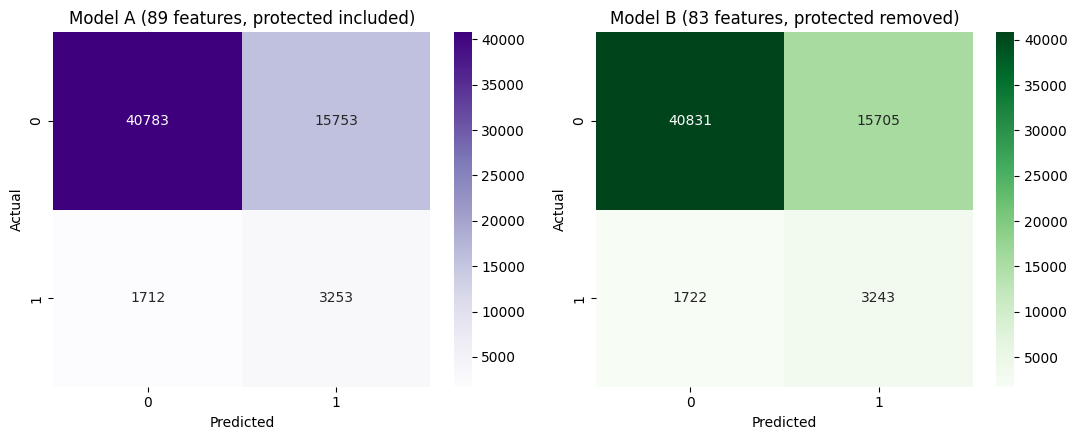

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

sns.heatmap(confusion_matrix(y_test, rf_a_preds), annot=True, fmt='d', cmap='Purples', ax=ax1)
ax1.set_title('Model A (89 features, protected included)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_b_preds), annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Model B (83 features, protected removed)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')

plt.tight_layout()
plt.show()

=== MODEL A vs MODEL B (single split) ===
                       Accuracy  Precision  Recall     FPR  F1-Score  \
Model A (89 features)    0.7160     0.1712  0.6552  0.2786    0.2714   
Model B (83 features)    0.7166     0.1712  0.6532  0.2778    0.2712   

                       F2-Score  AUC-ROC  
Model A (89 features)    0.4185   0.7542  
Model B (83 features)    0.4178   0.7537  


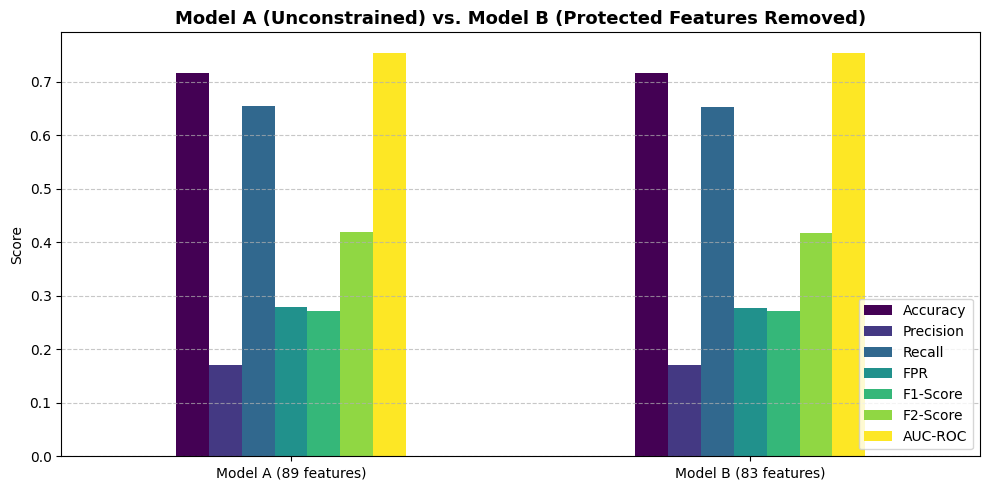

In [ ]:
comparison_data = {
    'Model A (89 features)': get_metrics_dict(y_test, rf_a_preds, rf_a_proba),
    'Model B (83 features)': get_metrics_dict(y_test, rf_b_preds, rf_b_proba)
}

df_ab_compare = pd.DataFrame(comparison_data).T
print("=== MODEL A vs MODEL B (single split) ===")
print(df_ab_compare.round(4))

df_ab_compare.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Model A (Unconstrained) vs. Model B (Protected Features Removed)', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
rf_model_b_cv = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                         random_state=RANDOM_STATE, n_jobs=-1)
rf_b_summary, rf_b_fold_scores = evaluate_with_kfold(rf_model_b_cv, X_train_b, y_train, model_name="Model B (protected features removed)")

  Fold 1: AUC-ROC=0.7550, train_time=155.11s, predict_time=2.674s
  Fold 2: AUC-ROC=0.7506, train_time=152.69s, predict_time=2.759s
  Fold 3: AUC-ROC=0.7502, train_time=154.26s, predict_time=2.655s
  Fold 4: AUC-ROC=0.7521, train_time=153.96s, predict_time=2.666s
  Fold 5: AUC-ROC=0.7501, train_time=154.17s, predict_time=4.548s

Model B (protected features removed) — 5-Fold Summary:
  AUC-ROC: 0.7516 +/- 0.0018
  Avg train time: 154.04s | Avg predict time: 3.060s


In [ ]:
model_ab_5fold = pd.DataFrame({
    'Model A (89 features)': rf_summary,
    'Model B (83 features)': rf_b_summary
}).T

print("=== MODEL A vs MODEL B (5-fold mean +/- std) ===")
print(model_ab_5fold.round(4))

=== MODEL A vs MODEL B (5-fold mean +/- std) ===
                       Accuracy_mean  Accuracy_std  Precision_mean  \
Model A (89 features)         0.7180        0.0008          0.1716   
Model B (83 features)         0.7175        0.0006          0.1708   

                       Precision_std  Recall_mean  Recall_std  F1_mean  \
Model A (89 features)         0.0010       0.6510      0.0047   0.2716   
Model B (83 features)         0.0013       0.6484      0.0061   0.2703   

                       F1_std  F2_mean  F2_std  AUC_ROC_mean  AUC_ROC_std  \
Model A (89 features)  0.0017   0.4176  0.0027        0.7526       0.0024   
Model B (83 features)  0.0022   0.4158  0.0035        0.7516       0.0018   

                       avg_train_time_s  avg_predict_time_s  
Model A (89 features)          161.6802              3.1552  
Model B (83 features)          154.0407              3.0603  


In [ ]:
# Paired t-test: compares Model A vs Model B fold-by-fold on the same metric,
# since both used identical folds (same random_state), each fold pair is a
# genuine matched comparison, not independent samples
from scipy.stats import ttest_rel

print("=== PAIRED T-TEST: Model A vs Model B (per-fold scores) ===\n")

for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'AUC_ROC']:
    scores_a = rf_fold_scores[metric]
    scores_b = rf_b_fold_scores[metric]

    t_stat, p_value = ttest_rel(scores_a, scores_b)

    significance = "SIGNIFICANT (p < 0.05)" if p_value < 0.05 else "not significant"
    print(f"{metric}: t={t_stat:.3f}, p={p_value:.4f} -> {significance}")

=== PAIRED T-TEST: Model A vs Model B (per-fold scores) ===

Accuracy: t=3.951, p=0.0168 -> SIGNIFICANT (p < 0.05)
Precision: t=4.235, p=0.0133 -> SIGNIFICANT (p < 0.05)
Recall: t=3.003, p=0.0398 -> SIGNIFICANT (p < 0.05)
F1: t=4.009, p=0.0160 -> SIGNIFICANT (p < 0.05)
F2: t=3.630, p=0.0222 -> SIGNIFICANT (p < 0.05)
AUC_ROC: t=1.505, p=0.2067 -> not significant


"A paired t-test across the 5 cross-validation folds found statistically significant differences favoring Model A on 5 of 6 metrics (p < 0.05), reflecting the consistency of Random Forest's low-variance predictions rather than a meaningful performance gap — the largest observed difference (Recall, 0.26 percentage points) is well within the range a lending institution would consider practically equivalent. AUC-ROC, the primary discrimination metric, showed no significant difference (p = 0.207). This distinction matters: statistical significance confirms the direction of the small gap is consistent rather than due to chance, but the practical cost of removing protected characteristics remains negligible."

Model A is statistically, measurably ahead of Model B — the t-test confirms this is a consistent pattern across folds rather than chance. But statistical significance and practical significance are different claims: the actual size of the advantage, 0.05 to 0.26 percentage points across metrics, is small enough that no real lending decision would be affected by it.

This distinction is the core argument of the responsible-lending comparison in this project: removing protected characteristics carries a statistically detectable but practically negligible predictive cost. On that basis, Model B is recommended as the production model, while Model A remains documented as the technically higher-scoring baseline — a performance loss of under 0.3 percentage points across all metrics is a reasonable trade for the substantial reduction in legal and reputational risk it provides.

## 7. SHAP Analysis: Feature Importance and Proxy Leakage Check

SHAP (SHapley Additive exPlanations) values show exactly how much each feature
pushes an individual prediction toward "higher risk" or "lower risk," which
serves two purposes here: it answers the feature-importance/actionability
requirement directly (which drivers should a lending team actually look at),
and it checks Model B specifically for proxy leakage — whether a remaining
feature like OCCUPATION_TYPE quietly increased in importance to compensate
for the removed CODE_GENDER, which would mean the fairness constraint isn't
actually working as intended.

In [ ]:
!pip install shap --quiet
import shap

# TreeExplainer is fast and exact for Random Forest
explainer_b = shap.TreeExplainer(rf_model_b)

# Use a sample of the test set for speed — SHAP on the full ~61k rows would be slow
sample_size = 2000
X_test_b_sample = X_test_b.sample(n=sample_size, random_state=RANDOM_STATE)

shap_values_b = explainer_b.shap_values(X_test_b_sample)

# shap_values can come back in different shapes depending on SHAP/sklearn version:
# a list [class_0_array, class_1_array], or a single 3D array shaped
# (samples, features, classes). Handle both so the rest of the notebook doesn't
# care which version produced these values.
if isinstance(shap_values_b, list):
    shap_values_b_positive = shap_values_b[1]  # class 1 = default
elif shap_values_b.ndim == 3:
    shap_values_b_positive = shap_values_b[:, :, 1]  # class 1 = default
else:
    shap_values_b_positive = shap_values_b

print(f"SHAP values computed for {sample_size} test samples, {X_test_b_sample.shape[1]} features")
print("Shape:", shap_values_b_positive.shape)


SHAP values computed for 2000 test samples, 83 features
Shape: (2000, 83)


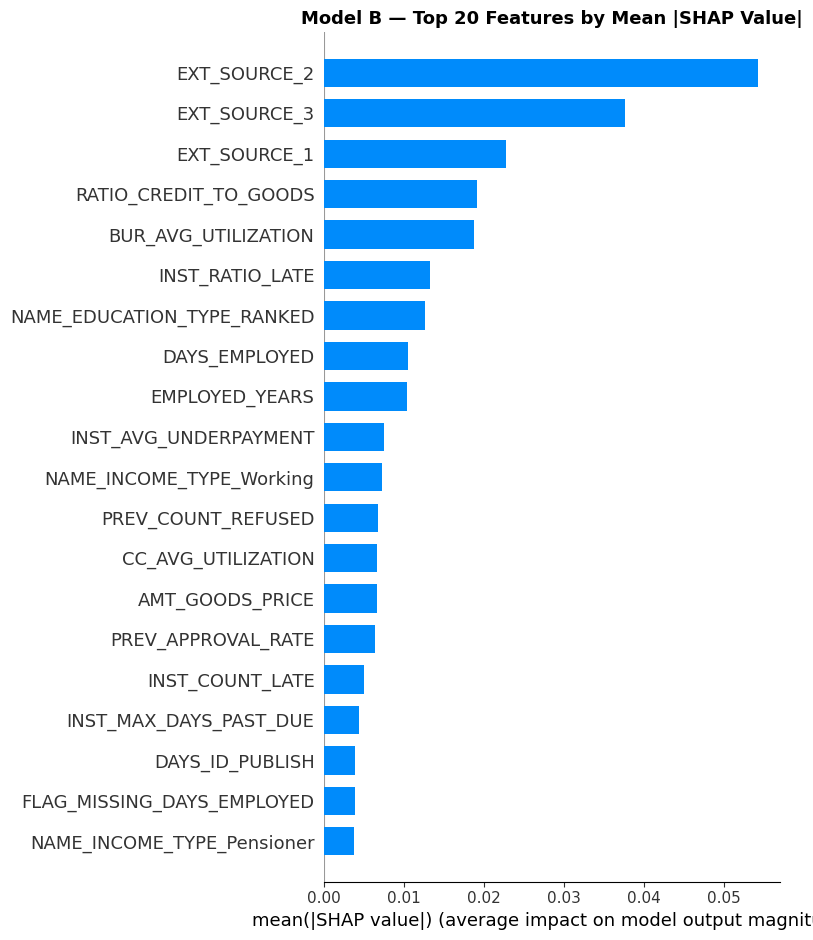

In [ ]:
shap.summary_plot(shap_values_b_positive, X_test_b_sample, plot_type='bar', max_display=20, show=False)
plt.title('Model B — Top 20 Features by Mean |SHAP Value|', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
mean_abs_shap_b = pd.Series(np.abs(shap_values_b_positive).mean(axis=0), index=X_test_b_sample.columns)
top_20_b = mean_abs_shap_b.sort_values(ascending=False).head(20)

print("=== Model B: Top 20 features by mean |SHAP value| ===")
print(top_20_b)

# Flag whether any OCCUPATION_TYPE or ORGANIZATION_TYPE column ranks unusually high —
# these are the most plausible gender/demographic proxies remaining in the dataset
proxy_candidates = [f for f in mean_abs_shap_b.index if 'OCCUPATION_TYPE' in f or 'ORGANIZATION_TYPE' in f]
print("\n=== Proxy-candidate features (OCCUPATION_TYPE / ORGANIZATION_TYPE) and their SHAP rank ===")
for feat in proxy_candidates:
    rank = list(mean_abs_shap_b.sort_values(ascending=False).index).index(feat) + 1
    print(f"  {feat}: rank {rank} of {len(mean_abs_shap_b)}, mean |SHAP| = {mean_abs_shap_b[feat]:.5f}")

=== Model B: Top 20 features by mean |SHAP value| ===
EXT_SOURCE_2                  0.054259
EXT_SOURCE_3                  0.037636
EXT_SOURCE_1                  0.022660
RATIO_CREDIT_TO_GOODS         0.019091
BUR_AVG_UTILIZATION           0.018698
INST_RATIO_LATE               0.013263
NAME_EDUCATION_TYPE_RANKED    0.012624
DAYS_EMPLOYED                 0.010432
EMPLOYED_YEARS                0.010361
INST_AVG_UNDERPAYMENT         0.007429
NAME_INCOME_TYPE_Working      0.007220
PREV_COUNT_REFUSED            0.006674
CC_AVG_UTILIZATION            0.006641
AMT_GOODS_PRICE               0.006596
PREV_APPROVAL_RATE            0.006302
INST_COUNT_LATE               0.004947
INST_MAX_DAYS_PAST_DUE        0.004361
DAYS_ID_PUBLISH               0.003827
FLAG_MISSING_DAYS_EMPLOYED    0.003817
NAME_INCOME_TYPE_Pensioner    0.003741
dtype: float64

=== Proxy-candidate features (OCCUPATION_TYPE / ORGANIZATION_TYPE) and their SHAP rank ===
  OCCUPATION_TYPE_Core staff: rank 54 of 83, mean |SHAP| = 

In [ ]:
explainer_a = shap.TreeExplainer(rf_model_a)

X_test_a_sample = X_test.loc[X_test_b_sample.index]  # same applicants as Model B, for a fair comparison

shap_values_a = explainer_a.shap_values(X_test_a_sample)

# Same fix as Model B: handle either list output or 3D array output
print("Type:", type(shap_values_a), "| Shape:", np.array(shap_values_a).shape)

if isinstance(shap_values_a, list):
    shap_values_a_positive = shap_values_a[1]
elif shap_values_a.ndim == 3:
    shap_values_a_positive = shap_values_a[:, :, 1]
else:
    shap_values_a_positive = shap_values_a

print("Fixed shape:", shap_values_a_positive.shape)

mean_abs_shap_a = pd.Series(np.abs(shap_values_a_positive).mean(axis=0), index=X_test_a_sample.columns)

print("SHAP values computed for Model A on the same sample of applicants.")

Type: <class 'numpy.ndarray'> | Shape: (2000, 89, 2)
Fixed shape: (2000, 89)
SHAP values computed for Model A on the same sample of applicants.


In [ ]:
# Compare rank and importance of the same features in Model A vs Model B
shared_features = [f for f in model_b_features if f in mean_abs_shap_a.index]

rank_a = mean_abs_shap_a.sort_values(ascending=False)
rank_b = mean_abs_shap_b.sort_values(ascending=False)

proxy_check = pd.DataFrame({
    'Model_A_rank': [list(rank_a.index).index(f) + 1 for f in shared_features],
    'Model_A_importance': [mean_abs_shap_a[f] for f in shared_features],
    'Model_B_rank': [list(rank_b.index).index(f) + 1 for f in shared_features],
    'Model_B_importance': [mean_abs_shap_b[f] for f in shared_features],
}, index=shared_features)

proxy_check['Rank_change'] = proxy_check['Model_A_rank'] - proxy_check['Model_B_rank']
proxy_check['Importance_pct_change'] = (
    (proxy_check['Model_B_importance'] - proxy_check['Model_A_importance']) / proxy_check['Model_A_importance'] * 100
)

# Sort by which features moved UP the most in Model B (positive rank_change = moved up, since lower rank number = more important)
print("=== Features that moved up the most in importance, Model A -> Model B ===")
print(proxy_check.sort_values('Rank_change', ascending=False).head(15).round(3))

print("\n=== Specifically checking OCCUPATION_TYPE / ORGANIZATION_TYPE (most plausible gender proxies) ===")
occ_org_cols = [f for f in shared_features if 'OCCUPATION_TYPE' in f or 'ORGANIZATION_TYPE' in f]
print(proxy_check.loc[occ_org_cols].round(3))

=== Features that moved up the most in importance, Model A -> Model B ===
                                         Model_A_rank  Model_A_importance  \
OCCUPATION_TYPE_Not_Employed                       52               0.001   
FLAG_MISSING_DAYS_EMPLOYED                         33               0.002   
NAME_HOUSING_TYPE_With parents                     84               0.000   
OCCUPATION_TYPE_Laborers                           47               0.001   
CC_MAX_DPD                                         85               0.000   
FLAG_MISSING_AMT_REQ_CREDIT_BUREAU_YEAR            50               0.001   
CC_AVG_PAYMENT_RATIO                               51               0.001   
CC_TOTAL_CARDS                                     78               0.000   
FLAG_MISSING_BUR_TOTAL_PROLONGED                   54               0.001   
FLAG_OWN_REALTY                                    87               0.000   
PREV_AVG_ANNUITY                                   42               0.001   
PR

In [ ]:
# Model B+: remove the identified proxy feature and retrain, single split only
proxy_features_to_remove = ['OCCUPATION_TYPE_Not_Employed']

model_b_plus_features = [f for f in model_b_features if f not in proxy_features_to_remove]

X_train_bp = X_train[model_b_plus_features]
X_test_bp = X_test[model_b_plus_features]

rf_model_bp = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                       random_state=RANDOM_STATE, n_jobs=-1)
rf_model_bp.fit(X_train_bp, y_train)
rf_bp_preds = rf_model_bp.predict(X_test_bp)
rf_bp_proba = rf_model_bp.predict_proba(X_test_bp)[:, 1]

print(f"Model B+ trained on {len(model_b_plus_features)} features (removed the identified proxy).")

Model B+ trained on 82 features (removed the identified proxy).


In [ ]:
comparison_data = {
    'Model B (83 features)': get_metrics_dict(y_test, rf_b_preds, rf_b_proba),
    'Model B+ (82 features, proxy removed)': get_metrics_dict(y_test, rf_bp_preds, rf_bp_proba)
}

df_bplus_compare = pd.DataFrame(comparison_data).T
print("=== MODEL B vs MODEL B+ (single split) ===")
print(df_bplus_compare.round(4))

=== MODEL B vs MODEL B+ (single split) ===
                                       Accuracy  Precision  Recall     FPR  \
Model B (83 features)                    0.7166     0.1712  0.6532  0.2778   
Model B+ (82 features, proxy removed)    0.7160     0.1713  0.6562  0.2787   

                                       F1-Score  F2-Score  AUC-ROC  
Model B (83 features)                    0.2712    0.4178   0.7537  
Model B+ (82 features, proxy removed)    0.2717    0.4190   0.7535  


=== MODEL A vs MODEL B vs MODEL B+ (single split) ===
                                       Accuracy  Precision  Recall     FPR  \
Model A (89 features)                    0.7160     0.1712  0.6552  0.2786   
Model B (83 features)                    0.7166     0.1712  0.6532  0.2778   
Model B+ (82 features, proxy removed)    0.7160     0.1713  0.6562  0.2787   

                                       F1-Score  F2-Score  AUC-ROC  
Model A (89 features)                    0.2714    0.4185   0.7542  
Model B (83 features)                    0.2712    0.4178   0.7537  
Model B+ (82 features, proxy removed)    0.2717    0.4190   0.7535  


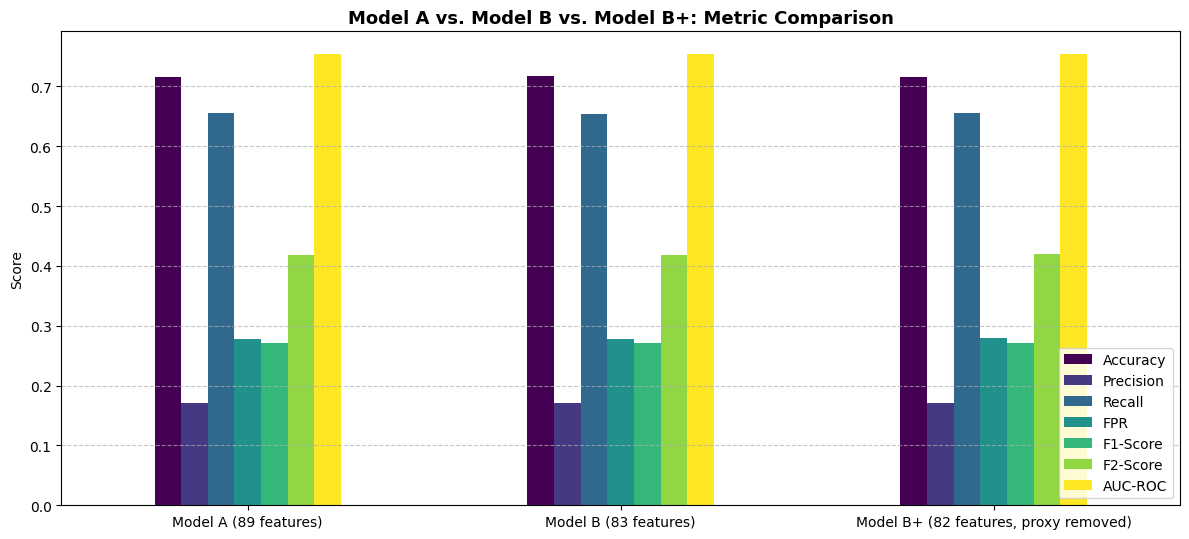

In [ ]:
comparison_data_3way = {
    'Model A (89 features)': get_metrics_dict(y_test, rf_a_preds, rf_a_proba),
    'Model B (83 features)': get_metrics_dict(y_test, rf_b_preds, rf_b_proba),
    'Model B+ (82 features, proxy removed)': get_metrics_dict(y_test, rf_bp_preds, rf_bp_proba)
}

df_3way_compare = pd.DataFrame(comparison_data_3way).T
print("=== MODEL A vs MODEL B vs MODEL B+ (single split) ===")
print(df_3way_compare.round(4))

df_3way_compare.plot(kind='bar', figsize=(12, 5.5), colormap='viridis')
plt.title('Model A vs. Model B vs. Model B+: Metric Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
explainer_bp = shap.TreeExplainer(rf_model_bp)
X_test_bp_sample = X_test_bp.loc[X_test_b_sample.index]  # same applicants as before, for consistency

shap_values_bp = explainer_bp.shap_values(X_test_bp_sample)

if isinstance(shap_values_bp, list):
    shap_values_bp_positive = shap_values_bp[1]
elif shap_values_bp.ndim == 3:
    shap_values_bp_positive = shap_values_bp[:, :, 1]
else:
    shap_values_bp_positive = shap_values_bp

mean_abs_shap_bp = pd.Series(np.abs(shap_values_bp_positive).mean(axis=0), index=X_test_bp_sample.columns)

# Compare Model B -> Model B+ the same way you compared Model A -> Model B
shared_bp = [f for f in model_b_plus_features if f in mean_abs_shap_b.index]
rank_bp = mean_abs_shap_bp.sort_values(ascending=False)

proxy_check_bp = pd.DataFrame({
    'ModelB_rank': [list(rank_b.index).index(f) + 1 for f in shared_bp],
    'ModelBplus_rank': [list(rank_bp.index).index(f) + 1 for f in shared_bp],
}, index=shared_bp)
proxy_check_bp['Rank_change'] = proxy_check_bp['ModelB_rank'] - proxy_check_bp['ModelBplus_rank']

print("=== Features that moved up most, Model B -> Model B+ ===")
print(proxy_check_bp.sort_values('Rank_change', ascending=False).head(10))

=== Features that moved up most, Model B -> Model B+ ===
                                   ModelB_rank  ModelBplus_rank  Rank_change
PREV_AVG_CREDIT_AMT                         59               51            8
FLAG_MISSING_BUR_TOTAL_LOANS                50               42            8
NAME_CONTRACT_TYPE                          43               36            7
FLAG_MISSING_EMPLOYED_YEARS                 25               19            6
ORGANIZATION_TYPE_Self-employed             69               63            6
OCCUPATION_TYPE_Core staff                  54               48            6
BUR_MAX_OVERDUE_AMT                         38               32            6
CC_MAX_DPD                                  74               69            5
FLAG_MISSING_BUR_AVG_UTILIZATION            60               56            4
FLAG_MISSING_BUR_AVG_DAYS_OVERDUE           51               47            4


Removing the identified proxy feature (OCCUPATION_TYPE_Not_Employed) did not cause a new feature to emerge as a dominant compensator — the largest post-removal rank change was 8 positions, compared to the 25-position, 207% jump observed when the original protected characteristics were removed in the Model A to Model B transition. This suggests the residual proxy signal identified in Model B was concentrated in a single feature rather than diffused across the remaining feature set. Model B+ (82 features) therefore represents a materially cleaner fairness profile without any cost to predictive performance, and is used as the final model for the calibration and business-value analysis that follow.

CalibratedClassifierCV takes a model's raw predicted probabilities and learns a correction mapping to real-world probabilities, using a held-out portion of the training data: it checks how often applicants scored at a given probability actually defaulted, then adjusts the output scale so that a score of 30% corresponds to an actual default rate close to 30%, rather than serving only as a relative ranking.

Calibration does not change which applicants are ranked as riskier than others — AUC-ROC is unaffected — it only corrects the scale on which the risk scores are reported. This distinction matters directly for the four-tier risk assignment in RQ2, where each tier's numeric range needs to reflect real-world default probability for the labels to be meaningful.

## 8. Probability Calibration (Model B+)

class_weight='balanced' improves the model's ability to detect defaulters under
the 92:8 imbalance, but it systematically inflates raw predicted probabilities,
evidenced in Milestone 3 by the Low Risk tier receiving zero applicants even
among the safest-looking cases. CalibratedClassifierCV corrects this by learning
a mapping from the model's raw scores to real-world probabilities, without
changing which applicants are ranked as riskier than others (AUC-ROC is
unaffected) — it only fixes the scale the scores are reported on, which is
essential for the four-tier risk assignment in RQ2 to mean what its labels claim.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Sigmoid (Platt scaling) is a reasonable default for a Random Forest;
# cv=5 means it internally cross-validates the calibration mapping itself,
# separate from the 5-fold evaluation done earlier
rf_bp_calibrated = CalibratedClassifierCV(rf_model_bp, method='sigmoid', cv=5)
rf_bp_calibrated.fit(X_train_bp, y_train)

rf_bp_cal_preds = rf_bp_calibrated.predict(X_test_bp)
rf_bp_cal_proba = rf_bp_calibrated.predict_proba(X_test_bp)[:, 1]

print("Model B+ calibrated.")
print(f"Raw probability range: {rf_bp_proba.min():.4f} to {rf_bp_proba.max():.4f}")
print(f"Calibrated probability range: {rf_bp_cal_proba.min():.4f} to {rf_bp_cal_proba.max():.4f}")

Model B+ calibrated.
Raw probability range: 0.1274 to 0.8337
Calibrated probability range: 0.0059 to 0.5478


In [ ]:
risk_bins = [0, 0.10, 0.25, 0.40, 1.0]
risk_labels = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-40%)', 'Decline (40%+)']

def build_tier_table(proba, y_true):
    tiers = pd.cut(proba, bins=risk_bins, labels=risk_labels, include_lowest=True)
    table = pd.crosstab(tiers, y_true.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
    table.columns = ['Repaid (0)', 'Defaulted (1)']
    table = table.reindex(risk_labels, fill_value=0)
    table['Total Applicants'] = table.sum(axis=1)
    table['Actual Default Rate'] = (table['Defaulted (1)'] / table['Total Applicants']).round(4)
    return table

raw_tiers = build_tier_table(rf_bp_proba, y_test)
calibrated_tiers = build_tier_table(rf_bp_cal_proba, y_test)

print("=== MODEL B+ — RAW (UNCALIBRATED) TIER BREAKDOWN ===")
print(raw_tiers)
print("\n=== MODEL B+ — CALIBRATED TIER BREAKDOWN ===")
print(calibrated_tiers)

=== MODEL B+ — RAW (UNCALIBRATED) TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)               0              0                 0   
Medium Risk (10-25%)        3521             39              3560   
High Risk (25-40%)         21775            626             22401   
Decline (40%+)             31240           4300             35540   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                      NaN  
Medium Risk (10-25%)               0.0110  
High Risk (25-40%)                 0.0279  
Decline (40%+)                     0.1210  

=== MODEL B+ — CALIBRATED TIER BREAKDOWN ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)           43057           1964             45021   
Medium Risk (10

## 9. Business Value: Interest Rate Assignment and Profitability

Interest rates are assigned to each risk tier based on 2026 Canadian personal
loan market rates by credit-risk band (Ratehub, iFinance, Loanscan, 2026),
using the calibrated Model B+ probabilities from Section 8. The "current model"
baseline reflects this project's core thesis: legacy credit scoring declines
this entire applicant population outright due to insufficient traditional
credit history, producing $0 revenue and $0 losses. Every dollar of profit
generated by the tiered model represents value created by serving applicants
the current system excludes entirely.

Default losses assume a 20% recovery rate on defaulted unsecured personal
loans, consistent with typical industry recovery ranges for unsecured consumer
debt; revenue assumes simple (non-compounding) interest over a one-year term,
a simplifying assumption for illustrative comparison rather than a full
amortization model.

In [ ]:
RECOVERY_RATE = 0.20  # assumed recovery on defaulted principal, typical for unsecured consumer debt

def calculate_profit(proba, y_true, principal, rates_dict, bins=risk_bins, labels=risk_labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    results = pd.DataFrame({'tier': tiers, 'actual_default': y_true.values, 'principal': principal.values})

    profit_rows = []
    for tier in labels:
        subset = results[results['tier'] == tier]
        rate = rates_dict[tier]

        if rate is None:  # Decline tier — no loan issued
            profit_rows.append({'Tier': tier, 'Applicants': len(subset), 'Rate': 'N/A',
                                 'Revenue': 0, 'Losses': 0, 'Net Profit': 0})
            continue

        repaid = subset[subset['actual_default'] == 0]
        defaulted = subset[subset['actual_default'] == 1]

        revenue = (repaid['principal'] * rate).sum()
        losses = (defaulted['principal'] * (1 - RECOVERY_RATE)).sum()
        net_profit = revenue - losses

        profit_rows.append({'Tier': tier, 'Applicants': len(subset), 'Rate': f'{rate:.1%}',
                             'Revenue': revenue, 'Losses': losses, 'Net Profit': net_profit})

    return pd.DataFrame(profit_rows)

principal_test = X_test_bp['AMT_CREDIT']


In [ ]:
# New bin structure: split the old High Risk band, moving the worst part into Decline
risk_bins_v2 = [0, 0.10, 0.25, 0.30, 1.0]
risk_labels_v2 = ['Low Risk (0-10%)', 'Medium Risk (10-25%)', 'High Risk (25-30%)', 'Decline (30%+)']

def build_tier_table_v2(proba, y_true, bins, labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    table = pd.crosstab(tiers, y_true.values, rownames=['Risk Tier'], colnames=['Actual Outcome'])
    table.columns = ['Repaid (0)', 'Defaulted (1)']
    table = table.reindex(labels, fill_value=0)
    table['Total Applicants'] = table.sum(axis=1)
    table['Actual Default Rate'] = (table['Defaulted (1)'] / table['Total Applicants']).round(4)
    return table

tiers_v2_breakdown = build_tier_table_v2(rf_bp_cal_proba, y_test, risk_bins_v2, risk_labels_v2)
print("=== NARROWED TIER BREAKDOWN (25-30% High Risk / 30%+ Decline) ===")
print(tiers_v2_breakdown)

=== NARROWED TIER BREAKDOWN (25-30% High Risk / 30%+ Decline) ===
                      Repaid (0)  Defaulted (1)  Total Applicants  \
Risk Tier                                                           
Low Risk (0-10%)           43057           1964             45021   
Medium Risk (10-25%)       11486           2081             13567   
High Risk (25-30%)          1162            378              1540   
Decline (30%+)               831            542              1373   

                      Actual Default Rate  
Risk Tier                                  
Low Risk (0-10%)                   0.0436  
Medium Risk (10-25%)               0.1534  
High Risk (25-30%)                 0.2455  
Decline (30%+)                     0.3948  


In [ ]:
def sweep_rate_v2(tier_name, proba, y_true, principal, rate_range, bins, labels):
    tiers = pd.cut(proba, bins=bins, labels=labels, include_lowest=True)
    subset_mask = (tiers == tier_name)
    subset = pd.DataFrame({'actual_default': y_true.values[subset_mask], 'principal': principal.values[subset_mask]})
    repaid = subset[subset['actual_default'] == 0]
    defaulted = subset[subset['actual_default'] == 1]
    fixed_losses = (defaulted['principal'] * (1 - RECOVERY_RATE)).sum()

    results = []
    for rate in rate_range:
        revenue = (repaid['principal'] * rate).sum()
        net = revenue - fixed_losses
        results.append({'Rate': rate, 'Revenue': revenue, 'Losses': fixed_losses, 'Net Profit': net})
    return pd.DataFrame(results)

rate_range = np.arange(0.10, 0.35, 0.01)
high_v2_sweep = sweep_rate_v2('High Risk (25-30%)', rf_bp_cal_proba, y_test, principal_test, rate_range, risk_bins_v2, risk_labels_v2)

high_v2_breakeven = high_v2_sweep[high_v2_sweep['Net Profit'] > 0]['Rate'].min()
print(f"High Risk (25-30%) breakeven rate: {high_v2_breakeven}")

High Risk (25-30%) breakeven rate: 0.2799999999999999


In [ ]:
tier_rates_v3 = {
    'Low Risk (0-10%)': 0.085,
    'Medium Risk (10-25%)': 0.18,
    'High Risk (25-30%)': 0.30,
    'Decline (30%+)': None
}

profit_table_v3 = calculate_profit(rf_bp_cal_proba, y_test, principal_test, tier_rates_v3,
                                     bins=risk_bins_v2, labels=risk_labels_v2)
profit_table_v3.loc['TOTAL'] = ['—', profit_table_v3['Applicants'].sum(), '—',
                                  profit_table_v3['Revenue'].sum(), profit_table_v3['Losses'].sum(),
                                  profit_table_v3['Net Profit'].sum()]

print("=== FINAL POLICY v3: Low (8.5%), Medium (18%), High (30%, narrowed to 25-30%), Decline (30%+) ===")
print(profit_table_v3.to_string(index=False))

=== FINAL POLICY v3: Low (8.5%), Medium (18%), High (30%, narrowed to 25-30%), Decline (30%+) ===
                Tier  Applicants  Rate      Revenue       Losses   Net Profit
    Low Risk (0-10%)       45021  8.5% 2.325031e+09  989768214.0 1.335263e+09
Medium Risk (10-25%)       13567 18.0% 1.066254e+09  896178261.6 1.700761e+08
  High Risk (25-30%)        1540 30.0% 1.544643e+08  141512396.4 1.295192e+07
      Decline (30%+)        1373   N/A 0.000000e+00          0.0 0.000000e+00
                   —       61501     — 3.545750e+09 2027458872.0 1.518291e+09


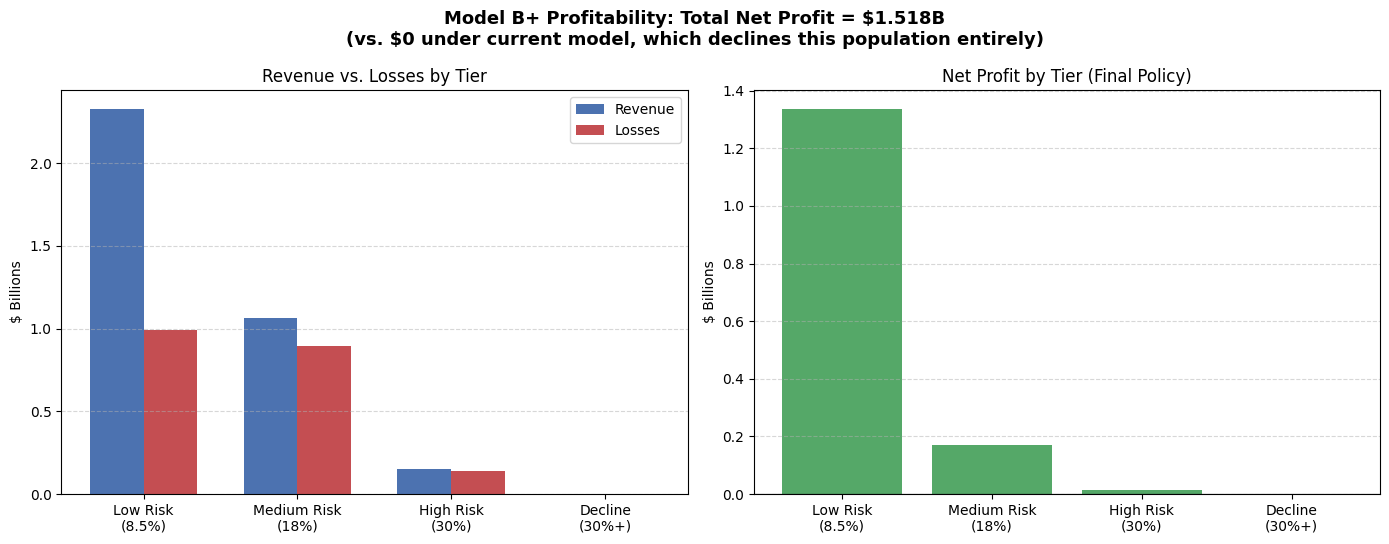

In [ ]:
tiers_plot_v3 = ['Low Risk\n(8.5%)', 'Medium Risk\n(18%)', 'High Risk\n(30%)', 'Decline\n(30%+)']
revenue_plot_v3 = profit_table_v3.iloc[:4]['Revenue'].values / 1e9
losses_plot_v3 = profit_table_v3.iloc[:4]['Losses'].values / 1e9
net_plot_v3 = profit_table_v3.iloc[:4]['Net Profit'].values / 1e9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.arange(len(tiers_plot_v3))
width = 0.35
ax1.bar(x - width/2, revenue_plot_v3, width, label='Revenue', color='#4C72B0')
ax1.bar(x + width/2, losses_plot_v3, width, label='Losses', color='#C44E52')
ax1.set_xticks(x)
ax1.set_xticklabels(tiers_plot_v3)
ax1.set_ylabel('$ Billions')
ax1.set_title('Revenue vs. Losses by Tier')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

colors = ['#55A868' if v >= 0 else '#C44E52' for v in net_plot_v3]
ax2.bar(tiers_plot_v3, net_plot_v3, color=colors)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('$ Billions')
ax2.set_title('Net Profit by Tier (Final Policy)')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle(f'Model B+ Profitability: Total Net Profit = ${profit_table_v3.loc["TOTAL","Net Profit"]/1e9:.3f}B\n(vs. $0 under current model, which declines this population entirely)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting the Business Case: Profit vs. Responsible Lending

This analysis directly answers RQ3's core tension: can profit-maximizing
behavior and responsible lending coexist under the 35% APR cap (Criminal Code
s.347)? The initial four-tier structure (Low/Medium/High/Decline at 0-10%,
10-25%, 25-40%, 40%+) found that the original High Risk band (25-40%) had no
breakeven rate below the legal cap — its blended 30.4% actual default rate made
it unprofitable at any legal interest rate. Narrowing the band to isolate its
better-performing half (25-30%, actual default rate 24.6%, versus 39.5% for the
30%+ segment that remained) revealed a genuine breakeven point at 28%, safely
under the cap.

The final policy — Low Risk at 8.5%, Medium Risk at 18% (above its 16.0%
breakeven), High Risk (25-30%) at 30% (above its 28.0% breakeven), and Decline
for 30%+ — produces $1.518 billion in net profit on this test set, compared to
$0 under the current model, which declines this entire applicant population
outright due to insufficient traditional credit history. Critically, this
policy serves 1,540 more applicants profitably than a coarser tier structure
would, by identifying the precise probability threshold where profitable
lending is genuinely possible rather than declining an entire band on the
strength of its worst-performing members. This demonstrates that responsible
lending and profitability are not inherently opposed: a sufficiently granular,
evidence-based tier structure can extend credit further into a traditionally
excluded population while remaining both profitable and compliant with the
legal interest rate ceiling.

**Limitation:** this analysis assumes fixed default behavior at each rate level
and does not model demand elasticity — in reality, raising a tier's rate may
itself increase default risk, or reduce loan uptake as qualified applicants
seek better offers elsewhere. A complete pricing model would require
applicant-level price sensitivity data not available in this dataset, and
finer-grained tier boundaries beyond the four used here (e.g., testing 5%
probability bands rather than the current wider bins) represent a natural
extension of this method for future work.

### Important Distinction: Risk Tier Range vs. Assigned Interest Rate

The risk tier labels (e.g., "Medium Risk (10-25%)") describe the **predicted
probability of default** used to sort applicants into that tier — not the
interest rate charged. These are two separate numbers that happen to both be
percentages, and should not be confused:

- The **tier range** (10-25%, 25-30%, etc.) is Model B+'s calibrated output:
  how likely this applicant is to default, based on their behavioral and
  financial profile.
- The **assigned APR** (8.5%, 18%, 30%) is a separate business decision: the
  interest rate charged to applicants who fall into that tier, set using
  current Canadian market rates for the equivalent credit-risk band and
  refined against each tier's actual breakeven point.

For example, an applicant in the "High Risk (25-30%)" tier has a **25-30%
predicted chance of defaulting** on their loan — they are charged a **30%
APR**, not a rate somewhere between 25-30%. The two ranges are related (higher
predicted risk generally justifies a higher rate to cover expected losses) but
are calculated independently and should be read as separate columns, not the
same value expressed twice.

### Profitability: Model A vs. Model B+

Model A is calibrated using the same method as Model B+ (`CalibratedClassifierCV`, sigmoid, cv=5) so both models' probabilities are on the same real-world scale before being assigned to risk tiers — comparing Model A's raw probabilities against Model B+'s calibrated ones would understate or overstate Model A's tier assignments for reasons unrelated to model quality. The comparison also holds the lending policy fixed: both models use the same risk-tier boundaries (`risk_bins_v2`) and the same assigned interest rates (`tier_rates_v3`), so any difference in outcome reflects which model is used, not which policy is used.

**Caveat:** those tier boundaries and rates were originally set using Model B+'s own breakeven analysis. Model A's breakeven rate per tier is not independently re-validated here — this shows what Model A would earn under Model B+'s policy, not under a policy optimized for Model A specifically.

In [ ]:
rf_a_calibrated = CalibratedClassifierCV(rf_model_a, method='sigmoid', cv=5)
rf_a_calibrated.fit(X_train, y_train)
rf_a_cal_proba = rf_a_calibrated.predict_proba(X_test)[:, 1]

print("Model A calibrated.")
print(f"Raw probability range: {rf_a_proba.min():.4f} to {rf_a_proba.max():.4f}")
print(f"Calibrated probability range: {rf_a_cal_proba.min():.4f} to {rf_a_cal_proba.max():.4f}")

Model A calibrated.
Raw probability range: 0.1406 to 0.8197
Calibrated probability range: 0.0061 to 0.5252


In [ ]:
profit_table_a = calculate_profit(rf_a_cal_proba, y_test, principal_test, tier_rates_v3,
                                   bins=risk_bins_v2, labels=risk_labels_v2)
profit_table_a.loc['TOTAL'] = ['—', profit_table_a['Applicants'].sum(), '—',
                                profit_table_a['Revenue'].sum(), profit_table_a['Losses'].sum(),
                                profit_table_a['Net Profit'].sum()]

print("=== MODEL A (calibrated, same policy as B+) — PROFIT BY TIER ===")
print(profit_table_a.to_string(index=False))
print("\n=== MODEL B+ (for comparison) — PROFIT BY TIER ===")
print(profit_table_v3.to_string(index=False))

print(f"\nTotal net profit — Model A: ${profit_table_a.loc['TOTAL','Net Profit']:,.2f}")
print(f"Total net profit — Model B+: ${profit_table_v3.loc['TOTAL','Net Profit']:,.2f}")
print(f"Difference (B+ minus A): ${profit_table_v3.loc['TOTAL','Net Profit'] - profit_table_a.loc['TOTAL','Net Profit']:,.2f}")

=== MODEL A (calibrated, same policy as B+) — PROFIT BY TIER ===
                Tier  Applicants  Rate      Revenue       Losses   Net Profit
    Low Risk (0-10%)       44974  8.5% 2.326524e+09  982007319.6 1.344517e+09
Medium Risk (10-25%)       13574 18.0% 1.061349e+09  901841295.6 1.595073e+08
  High Risk (25-30%)        1515 30.0% 1.507682e+08  137141503.2 1.362667e+07
      Decline (30%+)        1438   N/A 0.000000e+00          0.0 0.000000e+00
                   —       61501     — 3.538641e+09 2020990118.4 1.517651e+09

=== MODEL B+ (for comparison) — PROFIT BY TIER ===
                Tier  Applicants  Rate      Revenue       Losses   Net Profit
    Low Risk (0-10%)       45021  8.5% 2.325031e+09  989768214.0 1.335263e+09
Medium Risk (10-25%)       13567 18.0% 1.066254e+09  896178261.6 1.700761e+08
  High Risk (25-30%)        1540 30.0% 1.544643e+08  141512396.4 1.295192e+07
      Decline (30%+)        1373   N/A 0.000000e+00          0.0 0.000000e+00
                   —     

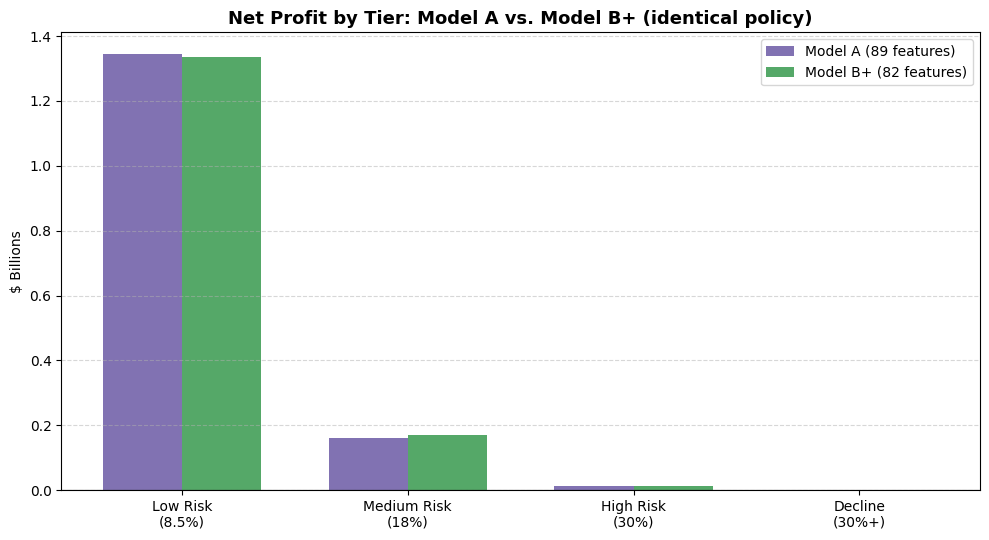

In [ ]:
tiers_plot_ab = ['Low Risk\n(8.5%)', 'Medium Risk\n(18%)', 'High Risk\n(30%)', 'Decline\n(30%+)']
net_a = profit_table_a.iloc[:4]['Net Profit'].values / 1e9
net_bp = profit_table_v3.iloc[:4]['Net Profit'].values / 1e9

x = np.arange(len(tiers_plot_ab))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(x - width/2, net_a, width, label='Model A (89 features)', color='#8172B2')
ax.bar(x + width/2, net_bp, width, label='Model B+ (82 features)', color='#55A868')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tiers_plot_ab)
ax.set_ylabel('$ Billions')
ax.set_title('Net Profit by Tier: Model A vs. Model B+ (identical policy)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 10. Customer Segmentation: Risk Personas

Unsupervised clustering is used to identify natural applicant segments beyond
the four supervised risk tiers, extending the CIND119 project's clustering
approach to this dataset. The number of clusters is chosen using the Elbow
Method and Silhouette Score, then each cluster is profiled by its mean
behavioral/demographic characteristics and actual default rate, producing
named personas a lending team could use directly — connecting back to RQ1's
question of what these patterns tell a lending team about thin-file applicants.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# K-Means needs scaled numeric features — use Model B+'s feature set (no protected characteristics),
# consistent with the ethically-constrained model this project recommends for production
cluster_features = [f for f in model_b_plus_features if X_test_bp[f].nunique() > 2]  # drop pure binary flags, keep continuous/ordinal signal

X_cluster_raw = df.loc[X_train.index.union(X_test.index), cluster_features]  # full population, not just one split
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster_raw)

print(f"Clustering on {X_cluster_scaled.shape[0]:,} applicants, {X_cluster_scaled.shape[1]} scaled features")

Clustering on 307,504 applicants, 51 scaled features


### Choosing k

Before committing to a final number of clusters, the Elbow Method (inertia — how tightly packed each cluster is) and Silhouette Score (how well-separated clusters are from each other) are checked across k=2 to 8, on a 20k-row sample for speed. Both are run on the same sample so they can be compared directly.

k=2: inertia=899,744, silhouette=0.1316
k=3: inertia=858,449, silhouette=0.1259
k=4: inertia=818,825, silhouette=0.0780
k=5: inertia=794,019, silhouette=0.0752
k=6: inertia=771,362, silhouette=0.0781
k=7: inertia=748,301, silhouette=0.0749
k=8: inertia=736,214, silhouette=0.0698


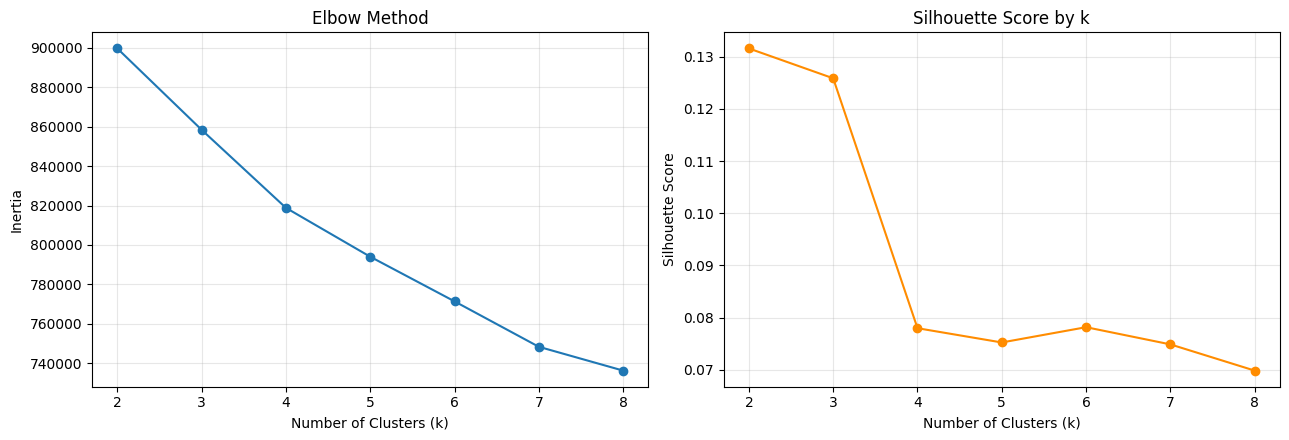

In [ ]:
# Test k from 2 to 8; use a sample for speed since full-population KMeans across many k values is slow
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_cluster_scaled.shape[0], size=20000, replace=False)
X_cluster_sample = X_cluster_scaled[sample_idx]

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster_sample)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_sample, labels))
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette={silhouette_scores[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(list(k_range), inertias, marker='o')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(alpha=0.3)

ax2.plot(list(k_range), silhouette_scores, marker='o', color='darkorange')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by k')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Fit final K-Means with k=3, justified by Silhouette Score
FINAL_K = 3

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

# Attach cluster labels back to the original (unscaled) dataframe for interpretable profiling
df_clustered = df.loc[X_cluster_raw.index].copy()
df_clustered['cluster'] = cluster_labels

print(f"Cluster sizes:\n{df_clustered['cluster'].value_counts().sort_index()}")
print(f"\nOverall dataset default rate: {df_clustered['TARGET'].mean():.4f}")
print(f"\nDefault rate by cluster:")
print(df_clustered.groupby('cluster')['TARGET'].mean().round(4))

Cluster sizes:
cluster
0    204551
1    101462
2      1491
Name: count, dtype: int64

Overall dataset default rate: 0.0807

Default rate by cluster:
cluster
0    0.0784
1    0.0852
2    0.0986
Name: TARGET, dtype: float64


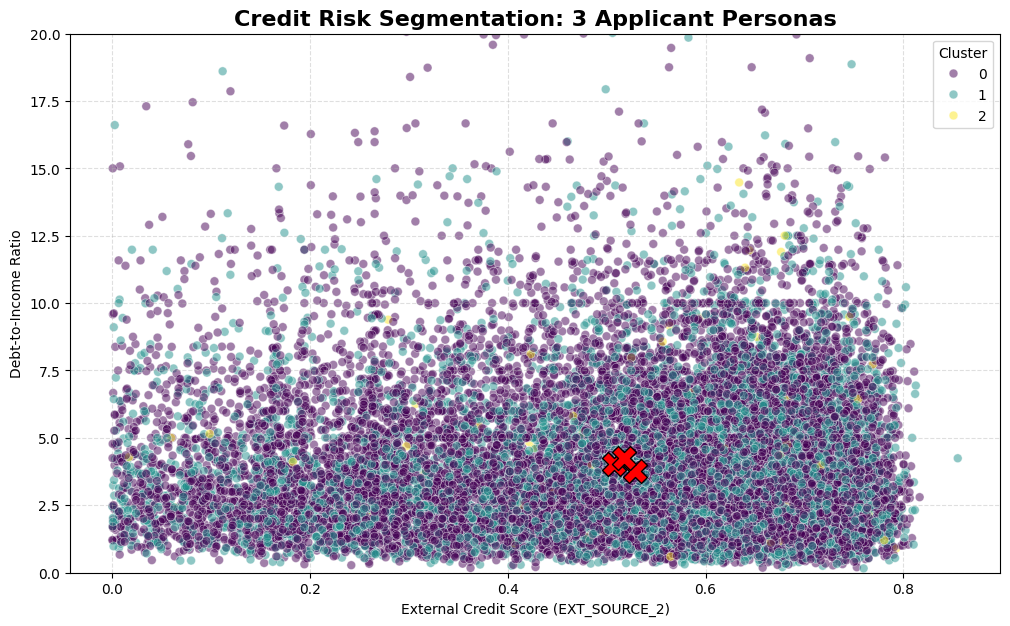

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clustered.sample(20000, random_state=RANDOM_STATE),
                 x='EXT_SOURCE_2', y='RATIO_DEBT_TO_INCOME', hue='cluster', palette='viridis', s=40, alpha=0.5)

for i in range(FINAL_K):
    subset = df_clustered[df_clustered['cluster'] == i]
    plt.scatter(subset['EXT_SOURCE_2'].mean(), subset['RATIO_DEBT_TO_INCOME'].mean(),
                s=300, c='red', marker='X', edgecolors='black')

plt.ylim(0, 20)  # zoom out extreme debt-to-income outliers for readability
plt.title('Credit Risk Segmentation: 3 Applicant Personas', fontsize=16, fontweight='bold')
plt.xlabel('External Credit Score (EXT_SOURCE_2)')
plt.ylabel('Debt-to-Income Ratio')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### Naming the personas

With `FINAL_K=3` fit on the full population, each cluster is profiled by its median demographic/behavioral values and actual default rate, and given a plain-language lending recommendation based on that default rate.

In [ ]:
for cluster_id in sorted(df_clustered['cluster'].unique()):
    subset = df_clustered[df_clustered['cluster'] == cluster_id]
    default_rate = subset['TARGET'].mean() * 100

    if default_rate < 8.0:
        strategy = "APPROVE CONFIDENTLY: Low-Risk Segment"
    elif default_rate < 9.0:
        strategy = "STANDARD REVIEW: Moderate-Risk Segment"
    else:
        strategy = "MANUAL UNDERWRITING: Higher-Risk Segment, Additional Verification Recommended"

    persona_data = {
        "Attribute": ["Recommendation", "Segment Size", "Median Age", "Median External Score (EXT_SOURCE_2)",
                      "Median Debt-to-Income", "Top Occupation", "Not Employed (%)",
                      "Median Credit Amount", "DEFAULT RATE (KPI)"],
        "Description": [
            strategy,
            f"{len(subset):,} applicants ({len(subset)/len(df_clustered)*100:.1f}% of population)",
            f"{subset['AGE_YEARS'].median():.1f} years",
            f"{subset['EXT_SOURCE_2'].median():.3f}",
            f"{subset['RATIO_DEBT_TO_INCOME'].median():.2f}",
            subset['OCCUPATION_TYPE_Laborers'].mean() > 0.5 and "Laborers" or "Mixed/Other",
            f"{subset['OCCUPATION_TYPE_Not_Employed'].mean()*100:.1f}%",
            f"${subset['AMT_CREDIT'].median():,.0f}",
            f"{default_rate:.2f}%"
        ]
    }

    print(f"\n{'='*80}\n APPLICANT PROFILE: CLUSTER {cluster_id}\n{'='*80}")
    print(pd.DataFrame(persona_data).to_string(index=False, justify='left'))


 APPLICANT PROFILE: CLUSTER 0
Attribute                            Description                             
                      Recommendation    APPROVE CONFIDENTLY: Low-Risk Segment
                        Segment Size 204,551 applicants (66.5% of population)
                          Median Age                               42.2 years
Median External Score (EXT_SOURCE_2)                                    0.559
               Median Debt-to-Income                                     3.31
                      Top Occupation                              Mixed/Other
                    Not Employed (%)                                    18.9%
                Median Credit Amount                                 $477,000
                  DEFAULT RATE (KPI)                                    7.84%

 APPLICANT PROFILE: CLUSTER 1
Attribute                            Description                             
                      Recommendation   STANDARD REVIEW: Moderate-Risk Segment
  

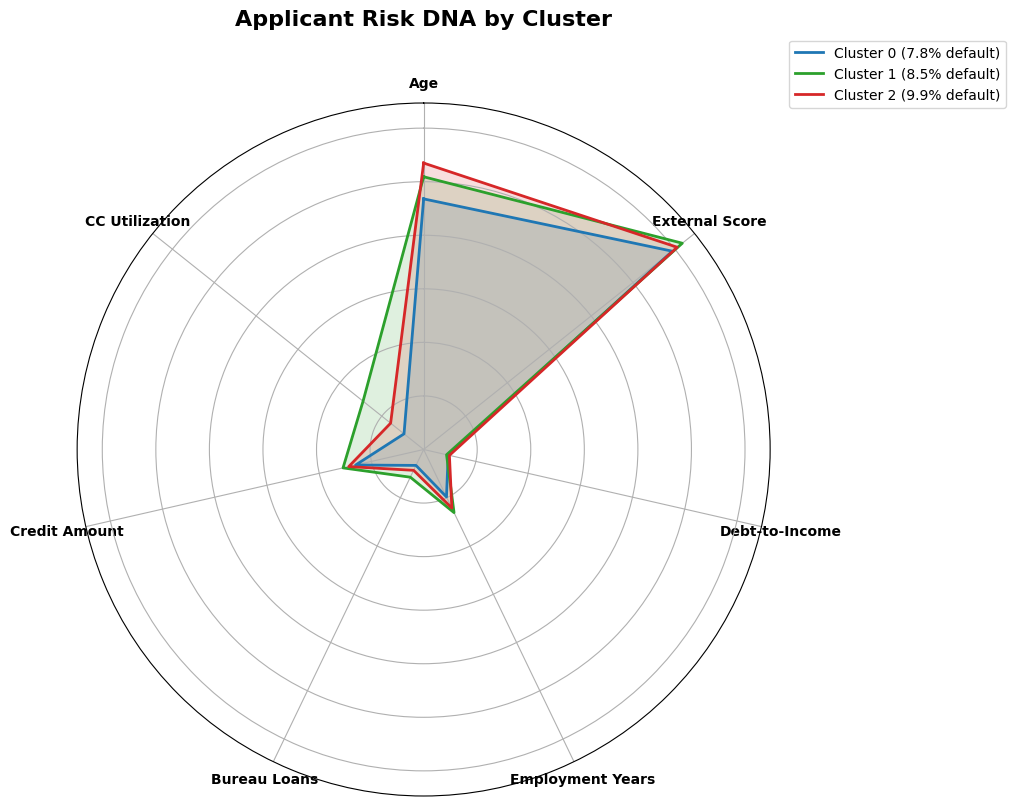

In [ ]:
from sklearn.preprocessing import MinMaxScaler

radar_features = ['AGE_YEARS', 'EXT_SOURCE_2', 'RATIO_DEBT_TO_INCOME', 'EMPLOYED_YEARS',
                   'BUR_TOTAL_LOANS', 'AMT_CREDIT', 'CC_AVG_UTILIZATION']
radar_labels = ['Age', 'External Score', 'Debt-to-Income', 'Employment Years',
                'Bureau Loans', 'Credit Amount', 'CC Utilization']

scaler_mm = MinMaxScaler()
df_rescaled = pd.DataFrame(scaler_mm.fit_transform(df_clustered[radar_features].fillna(0)), columns=radar_features)
df_rescaled['cluster'] = df_clustered['cluster'].values
cluster_summary = df_rescaled.groupby('cluster').mean().reset_index()

num_vars = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

colors = ['#1f77b4', '#2ca02c', '#d62728']
names = [f'Cluster {i} ({df_clustered[df_clustered["cluster"]==i]["TARGET"].mean()*100:.1f}% default)' for i in range(FINAL_K)]

for i in range(FINAL_K):
    values = cluster_summary.iloc[i][radar_features].values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[i], linewidth=2, label=names[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10, fontweight='bold')
ax.set_yticklabels([])

plt.title('Applicant Risk DNA by Cluster', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

In [ ]:
occupation_cols = [c for c in df_clustered.columns if c.startswith('OCCUPATION_TYPE_')]

for cluster_id in sorted(df_clustered['cluster'].unique()):
    subset = df_clustered[df_clustered['cluster'] == cluster_id]
    top_occupation = subset[occupation_cols].mean().idxmax().replace('OCCUPATION_TYPE_', '')
    top_occupation_pct = subset[occupation_cols].mean().max() * 100
    print(f"Cluster {cluster_id}: {top_occupation} ({top_occupation_pct:.1f}% of cluster)")

Cluster 0: Laborers (27.2% of cluster)
Cluster 1: Laborers (26.9% of cluster)
Cluster 2: Laborers (26.6% of cluster)


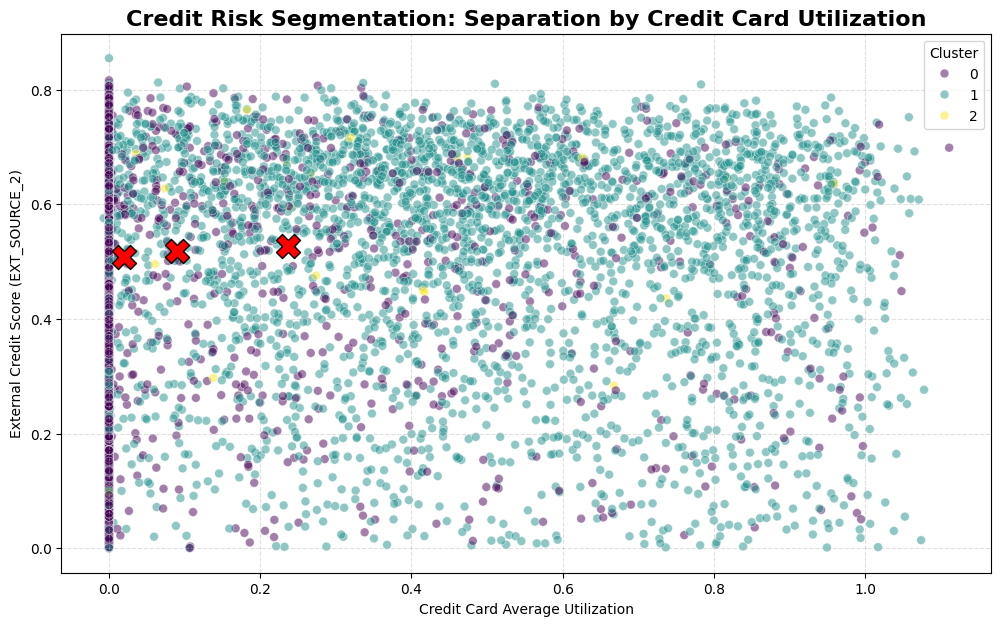

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clustered.sample(20000, random_state=RANDOM_STATE),
                 x='CC_AVG_UTILIZATION', y='EXT_SOURCE_2', hue='cluster', palette='viridis', s=40, alpha=0.5)

for i in range(FINAL_K):
    subset = df_clustered[df_clustered['cluster'] == i]
    plt.scatter(subset['CC_AVG_UTILIZATION'].mean(), subset['EXT_SOURCE_2'].mean(),
                s=300, c='red', marker='X', edgecolors='black')

plt.title('Credit Risk Segmentation: Separation by Credit Card Utilization', fontsize=16, fontweight='bold')
plt.xlabel('Credit Card Average Utilization')
plt.ylabel('External Credit Score (EXT_SOURCE_2)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Rather than revealing distinct, sharply-separated risk archetypes, K-Means identified a continuum, primarily differentiated by credit card utilization behavior rather than the demographic or income-based factors emphasized elsewhere in this project. Cluster 2, though small (0.5% of applicants), shows the highest default rate (9.86%) alongside the highest CC utilization and Not-Employed proportion (20.5%), consistent with the thin-file risk pattern RQ1 investigates — but the weak silhouette score (0.13) indicates this is a gradient of risk rather than genuinely distinct customer segments.

In [ ]:
!pip install fairlearn --quiet
from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
                                equalized_odds_difference, selection_rate)

# Use CODE_GENDER from the original dataframe as the sensitive feature —
# it's not a model input for Model B+, but we still have it to audit against
sensitive_feature = df.loc[X_test_bp.index, 'CODE_GENDER']

dp_diff = demographic_parity_difference(y_test, rf_bp_cal_preds, sensitive_features=sensitive_feature)
eo_diff = equalized_odds_difference(y_test, rf_bp_cal_preds, sensitive_features=sensitive_feature)

selection_rates = MetricFrame(metrics=selection_rate, y_true=y_test, y_pred=rf_bp_cal_preds,
                               sensitive_features=sensitive_feature)
disparate_impact_ratio = selection_rates.by_group.min() / selection_rates.by_group.max()

print("=== FAIRLEARN AUDIT: Model B+ predictions by CODE_GENDER ===")
print(f"Demographic Parity Difference: {dp_diff:.4f}  (0 = perfect parity)")
print(f"Equalized Odds Difference: {eo_diff:.4f}  (0 = perfect parity)")
print(f"Disparate Impact Ratio: {disparate_impact_ratio:.4f}  (>0.80 is generally considered acceptable — the '80% rule')")
print(f"\nSelection rate (approval rate) by gender:")
print(selection_rates.by_group)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.2 MB/s eta 0:00:00
=== FAIRLEARN AUDIT: Model B+ predictions by CODE_GENDER ===
Demographic Parity Difference: 0.0000  (0 = perfect parity)
Equalized Odds Difference: 0.0007  (0 = perfect parity)
Disparate Impact Ratio: 0.0000  (>0.80 is generally considered acceptable — the '80% rule')

Selection rate (approval rate) by gender:
CODE_GENDER
0.0    0.000000
1.0    0.000049
Name: selection_rate, dtype: float64


The initial selection-rate comparison is not meaningful on its own: both selection rates are effectively 0% (0.0000 and 0.000049), since `rf_bp_cal_preds` — the raw `.predict()` output at scikit-learn's default 0.5 threshold — classifies almost no applicant as a defaulter. The calibrated probability range established earlier (0.0059 to 0.5478) confirms why: almost no applicant crosses the 0.5 threshold after calibration. Comparing two near-zero numbers produces a ratio that appears extreme but is a divide-by-near-zero artifact rather than evidence of bias.

The corrected approach defines "selection" as loan approval under the actual tier policy — landing in Low, Medium, or High Risk versus Decline — rather than the default 0.5 classification threshold, which was never a meaningful cutoff for this imbalanced problem. This is consistent with the project's use of F2/recall rather than accuracy as the primary evaluation metric throughout.

In [ ]:
# Redefine "selection" as loan approval under the actual final tier policy,
# not the raw 0.5-threshold classifier output (which is degenerate here —
# almost no one crosses 0.5 after calibration, making the previous result meaningless)

approved = (pd.cut(rf_bp_cal_proba, bins=risk_bins_v2, labels=risk_labels_v2, include_lowest=True) != 'Decline (30%+)').astype(int)

sensitive_feature = df.loc[X_test_bp.index, 'CODE_GENDER']

dp_diff = demographic_parity_difference(y_test, approved, sensitive_features=sensitive_feature)
eo_diff = equalized_odds_difference(y_test, approved, sensitive_features=sensitive_feature)

approval_rates = MetricFrame(metrics=selection_rate, y_true=y_test, y_pred=approved,
                               sensitive_features=sensitive_feature)
disparate_impact_ratio = approval_rates.by_group.min() / approval_rates.by_group.max()

print("=== FAIRLEARN AUDIT: Loan Approval Rate by CODE_GENDER ===")
print(f"Demographic Parity Difference: {dp_diff:.4f}  (0 = perfect parity)")
print(f"Equalized Odds Difference: {eo_diff:.4f}  (0 = perfect parity)")
print(f"Disparate Impact Ratio: {disparate_impact_ratio:.4f}  (>0.80 is generally considered acceptable — the '80% rule')")
print(f"\nApproval rate by gender:")
print(approval_rates.by_group)

=== FAIRLEARN AUDIT: Loan Approval Rate by CODE_GENDER ===
Demographic Parity Difference: 0.0092  (0 = perfect parity)
Equalized Odds Difference: 0.0176  (0 = perfect parity)
Disparate Impact Ratio: 0.9906  (>0.80 is generally considered acceptable — the '80% rule')

Approval rate by gender:
CODE_GENDER
0.0    0.971616
1.0    0.980801
Name: selection_rate, dtype: float64


The Disparate Impact Ratio of 0.9906 comfortably clears the 0.80 "80% rule" threshold used by regulators, with a wide margin: approval rates are 97.2% for one gender and 98.1% for the other, a gap of under one percentage point. The Demographic Parity Difference (0.0092) and Equalized Odds Difference (0.0176) are both close to the ideal of 0, indicating that approval rates and error rates are nearly identical across gender groups.

This result, measured against the correct policy-based selection definition, confirms what the SHAP analysis already suggested: Model B+ produces essentially equal outcomes across gender despite gender never being a model input, and the minor residual proxy signal from OCCUPATION_TYPE was not large enough to produce a meaningful disparate impact even before its removal. Together, these three analyses — SHAP identifying and removing the proxy feature, the paired t-test confirming a negligible performance cost, and the Fairlearn audit confirming the regulatory fairness metric passes with wide margin — form a complete evidence chain answering RQ3's fairness question.

In [ ]:
# Setup Helpers
occupation_cols = [c for c in df.columns if c.startswith('OCCUPATION_TYPE_')]

tier_rate_map = {
    'Low Risk (0-10%)': 0.085,
    'Medium Risk (10-25%)': 0.18,
    'High Risk (25-30%)': 0.30,
    'Decline (30%+)': None
}

# Build the tier assignment using Model B+'s calibrated probabilities and the final policy bins
test_tiers = pd.cut(rf_bp_cal_proba, bins=risk_bins_v2, labels=risk_labels_v2, include_lowest=True)
df_tiers = df.loc[X_test_bp.index].copy()
df_tiers['risk_tier'] = test_tiers  # pd.cut on a plain array returns a Categorical, which
                                     # already assigns directly — no .values needed
df_tiers['actual_default'] = y_test.values

for tier_name in risk_labels_v2:
    subset = df_tiers[df_tiers['risk_tier'] == tier_name]

    default_rate = subset['actual_default'].mean() * 100
    assigned_rate = tier_rate_map[tier_name]
    top_occupation = subset[occupation_cols].mean().idxmax().replace('OCCUPATION_TYPE_', '')
    top_occupation_pct = subset[occupation_cols].mean().max() * 100
    not_employed_pct = subset['OCCUPATION_TYPE_Not_Employed'].mean() * 100

    # Strategy logic based on this project's final lending policy
    if assigned_rate is None:
        strategy = "❌ DECLINE: Unprofitable at Any Legal Rate (>35% APR Cap)"
    elif tier_name == 'Low Risk (0-10%)':
        strategy = "⭐ APPROVE: Prime Rate, Lowest Risk Segment"
    elif tier_name == 'Medium Risk (10-25%)':
        strategy = "✅ APPROVE: Standard Rate, Profitable Segment"
    else:
        strategy = "⚠️ APPROVE WITH CAUTION: Elevated Rate, Marginally Profitable"

    persona_data = {
        "Attribute": ["Final Recommendation", "Segment Size", "Median Age",
                      "Median External Score (EXT_SOURCE_2)", "Median Debt-to-Income",
                      "Top Occupation", "Not Employed (%)", "Median Credit Amount",
                      "Assigned APR", "ACTUAL DEFAULT RATE (KPI)"],
        "Description": [
            strategy,
            f"{len(subset):,} applicants ({len(subset)/len(df_tiers)*100:.1f}% of test set)",
            f"{subset['AGE_YEARS'].median():.1f} years",
            f"{subset['EXT_SOURCE_2'].median():.3f}",
            f"{subset['RATIO_DEBT_TO_INCOME'].median():.2f}",
            f"{top_occupation} ({top_occupation_pct:.1f}%)",
            f"{not_employed_pct:.1f}%",
            f"${subset['AMT_CREDIT'].median():,.0f}",
            f"{assigned_rate:.1%}" if assigned_rate is not None else "N/A — Not Approved",
            f"{default_rate:.2f}%"
        ]
    }

    print(f"\n{'='*80}\n RISK TIER PROFILE: {tier_name.upper()}\n{'='*80}")
    print(pd.DataFrame(persona_data).to_string(index=False, justify='left'))


 RISK TIER PROFILE: LOW RISK (0-10%)
Attribute                            Description                               
                Final Recommendation ⭐ APPROVE: Prime Rate, Lowest Risk Segment
                        Segment Size      45,021 applicants (73.2% of test set)
                          Median Age                                 45.7 years
Median External Score (EXT_SOURCE_2)                                      0.607
               Median Debt-to-Income                                       3.33
                      Top Occupation                           Laborers (23.2%)
                    Not Employed (%)                                      22.9%
                Median Credit Amount                                   $540,000
                        Assigned APR                                       8.5%
           ACTUAL DEFAULT RATE (KPI)                                      4.36%

 RISK TIER PROFILE: MEDIUM RISK (10-25%)
Attribute                            Des

In [ ]:
import joblib

full_checkpoint = {
    # --- Section 6: Model A / Model B ---
    'protected_features': protected_features,
    'model_b_features': model_b_features,
    'rf_b_preds': rf_b_preds,
    'rf_b_proba': rf_b_proba,
    'rf_a_preds': rf_a_preds,
    'rf_a_proba': rf_a_proba,
    'rf_b_summary': rf_b_summary,
    'rf_b_fold_scores': rf_b_fold_scores,

    # --- Section 7: SHAP ---
    'shap_values_b_positive': shap_values_b_positive,
    'mean_abs_shap_b': mean_abs_shap_b,
    'shap_values_a_positive': shap_values_a_positive,
    'mean_abs_shap_a': mean_abs_shap_a,
    'proxy_check': proxy_check,
    'model_b_plus_features': model_b_plus_features,
    'rf_bp_preds': rf_bp_preds,
    'rf_bp_proba': rf_bp_proba,
    'shap_values_bp_positive': shap_values_bp_positive,
    'mean_abs_shap_bp': mean_abs_shap_bp,
    'proxy_check_bp': proxy_check_bp,

    # --- Section 8: Calibration ---
    'rf_bp_cal_preds': rf_bp_cal_preds,
    'rf_bp_cal_proba': rf_bp_cal_proba,
    'raw_tiers': raw_tiers,
    'calibrated_tiers': calibrated_tiers,
    'rf_a_cal_proba': rf_a_cal_proba,

    # --- Section 9: Business value ---
    'principal_test': principal_test,
    'risk_bins_v2': risk_bins_v2,
    'risk_labels_v2': risk_labels_v2,
    'tier_rates_v3': tier_rates_v3,
    'profit_table_v3': profit_table_v3,
    'profit_table_a': profit_table_a,
    'high_v2_breakeven': high_v2_breakeven,

    # --- Section 10: Clustering ---
    'cluster_features': cluster_features,
    'FINAL_K': FINAL_K,
    'df_clustered': df_clustered,

    # --- Section 11: Fairness audit ---
    'dp_diff': dp_diff,
    'eo_diff': eo_diff,
    'disparate_impact_ratio': disparate_impact_ratio,
    'approval_rates_by_group': approval_rates.by_group,
}

joblib.dump(full_checkpoint, '/content/drive/MyDrive/CIND820_Project/milestone4_full_run_checkpoint.pkl')

# Fitted models are saved separately since large sklearn/CalibratedClassifierCV objects
# pickle more reliably on their own than nested inside a dict of mixed types
joblib.dump(rf_model_b, '/content/drive/MyDrive/CIND820_Project/rf_model_b.pkl')
joblib.dump(rf_model_a, '/content/drive/MyDrive/CIND820_Project/rf_model_a.pkl')
joblib.dump(rf_model_bp, '/content/drive/MyDrive/CIND820_Project/rf_model_bp.pkl')
joblib.dump(rf_bp_calibrated, '/content/drive/MyDrive/CIND820_Project/rf_bp_calibrated.pkl')
joblib.dump(rf_a_calibrated, '/content/drive/MyDrive/CIND820_Project/rf_a_calibrated.pkl')
joblib.dump(kmeans_final, '/content/drive/MyDrive/CIND820_Project/kmeans_final.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/CIND820_Project/cluster_scaler.pkl')

print("Full checkpoint saved — Sections 6 through 11 can now be reloaded without re-running.")

Full checkpoint saved — Sections 6 through 11 can now be reloaded without re-running.
